In [3]:

# ---- STEP 0.1: Google Drive Mount ----
# Yeh SABSE PEHLE chalao — har nayi session mein bhi
from google.colab import drive
drive.mount('/content/drive')



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:

# ---- STEP 0.2: Project Folder Structure ----
import os

BASE = '/content/drive/MyDrive/fraud_detection'  # ← Yeh apna folder path hai

folders = [
    f'{BASE}/data/raw',
    f'{BASE}/data/processed',
    f'{BASE}/models',
    f'{BASE}/reports',
]
for f in folders:
    os.makedirs(f, exist_ok=True)
    print(f'Created: {f}')

print('\n✅ Folder structure ready!')



Created: /content/drive/MyDrive/fraud_detection/data/raw
Created: /content/drive/MyDrive/fraud_detection/data/processed
Created: /content/drive/MyDrive/fraud_detection/models
Created: /content/drive/MyDrive/fraud_detection/reports

✅ Folder structure ready!


In [5]:
# ---- STEP 0.3: Libraries Install ----
# Run karo — 1-2 minute lagenge
import subprocess
subprocess.run(['pip', 'install', 'plotly', 'streamlit', 'pyngrok', 'joblib', '--quiet'])

import pandas as pd
import numpy as np
import sklearn
import plotly

print('pandas  :', pd.__version__)
print('numpy   :', np.__version__)
print('sklearn :', sklearn.__version__)
print('plotly  :', plotly.__version__)
print('\n✅ Sab libraries ready hain!')

pandas  : 2.2.2
numpy   : 2.0.2
sklearn : 1.6.1
plotly  : 5.24.1

✅ Sab libraries ready hain!


In [6]:
# ==============================================================
# DAY 1 — STEP 1.1b: Already Downloaded CMS File Use Karna
# ==============================================================

from google.colab import drive
import os

# Google Drive mount karo
drive.mount('/content/drive')

# Tumhari already downloaded CMS file ka exact path
cms_save = '/content/drive/MyDrive/MUP_PHY_R25_P05_V20_D23_Prov_Svc.csv'

# File check karo
if os.path.exists(cms_save):
    size_mb = os.path.getsize(cms_save) / (1024 * 1024)
    print("✅ CMS file mil gayi!")
    print("File path:", cms_save)
    print(f"File size: {size_mb:.2f} MB")
else:
    print("❌ CMS file nahi mili. Path check karo:")
    print(cms_save)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ CMS file mil gayi!
File path: /content/drive/MyDrive/MUP_PHY_R25_P05_V20_D23_Prov_Svc.csv
File size: 2920.47 MB


In [7]:
cms_save = '/content/drive/MyDrive/MUP_PHY_R25_P05_V20_D23_Prov_Svc.csv'

In [8]:
# ---- STEP 1.1b: Manual Upload Confirm ----

import os

cms_path = '/content/drive/MyDrive/MUP_PHY_R25_P05_V20_D23_Prov_Svc.csv'

if os.path.exists(cms_path):
    size_mb = os.path.getsize(cms_path) / (1024 * 1024)
    print(f'✅ CMS file mil gayi: {size_mb:.0f} MB')
    print('File path:', cms_path)
else:
    print('❌ CMS file nahi mili — path check karo')
    print(cms_path)

✅ CMS file mil gayi: 2920 MB
File path: /content/drive/MyDrive/MUP_PHY_R25_P05_V20_D23_Prov_Svc.csv


In [9]:
# ---- STEP 1.2: LEIE Download (Small File — Direct Download) ----

import requests
import os

BASE = '/content/drive/MyDrive/fraud_detection'

leie_url = 'https://oig.hhs.gov/exclusions/downloadables/UPDATED.csv'
leie_save = f'{BASE}/data/raw/leie_exclusions.csv'

try:
    r = requests.get(leie_url, timeout=30)

    if r.status_code == 200:
        with open(leie_save, 'wb') as fp:
            fp.write(r.content)

        size_kb = len(r.content) / 1024
        print(f'✅ LEIE downloaded: {size_kb:.0f} KB')
        print(f'   Saved: {leie_save}')
    else:
        print(f'❌ Download failed. Status code: {r.status_code}')

except Exception as e:
    print(f'❌ Error: {e}')
    print('Manual link: https://oig.hhs.gov/exclusions/exclusions_list.asp')
    print('CSV download karke Drive/fraud_detection/data/raw/ mein daalo')

✅ LEIE downloaded: 15106 KB
   Saved: /content/drive/MyDrive/fraud_detection/data/raw/leie_exclusions.csv


In [10]:
# ---- STEP 1.3: Files Verify ----

import os

BASE = '/content/drive/MyDrive/fraud_detection'

print('=== FILES CHECK ===')

for root, dirs, files in os.walk(f'{BASE}/data/raw'):
    for file in files:
        path = os.path.join(root, file)
        size_mb = os.path.getsize(path) / (1024 * 1024)
        print(f'✅ {file}  —  {size_mb:.1f} MB')

=== FILES CHECK ===
✅ leie_exclusions.csv  —  14.8 MB


In [11]:
import pandas as pd

leie_path = f'{BASE}/data/raw/leie_exclusions.csv'

leie_df = pd.read_csv(leie_path, nrows=5)

print("✅ LEIE file read ho gayi")
display(leie_df)

print("Columns:")
print(leie_df.columns.tolist())

✅ LEIE file read ho gayi


,LASTNAME,FIRSTNAME,MIDNAME,BUSNAME,GENERAL,SPECIALTY,UPIN,NPI,DOB,ADDRESS,CITY,STATE,ZIP,EXCLTYPE,EXCLDATE,REINDATE,WAIVERDATE,WVRSTATE
0,NaN,NaN,NaN,"#1 MARKETING SERVICE, INC",OTHER BUSINESS,SOBER HOME,NaN,0,NaN,239 BRIGHTON BEACH AVENUE,BROOKLYN,NY,11235,1128a1,20200319,0,0,NaN
1,NaN,NaN,NaN,"1 BEST CARE, INC",OTHER BUSINESS,HOME HEALTH AGENCY,NaN,0,NaN,"2161 UNIVERSITY AVENUE W, STE",SAINT PAUL,MN,55114,1128b5,20230518,0,0,NaN
2,NaN,NaN,NaN,101 FIRST CARE PHARMACY INC,OTHER BUSINESS,PHARMACY,NaN,1972902351,NaN,"C/O 609 W 191ST STREET, APT D",NEW YORK,NY,10040,1128b8,20220320,0,0,NaN
3,NaN,NaN,NaN,14 LAWRENCE AVE PHARMACY,PHARMACY,NaN,NaN,0,NaN,14 LAWRENCE AVENUE,SMITHTOWN,NY,11787,1128a1,19880830,0,0,NaN
4,NaN,NaN,NaN,143 MEDICAL EQUIPMENT CO,DME COMPANY,DME - OXYGEN,NaN,0,NaN,701 NW 36 AVENUE,MIAMI,FL,33125,1128b7,19970620,0,0,NaN


Columns:
['LASTNAME', 'FIRSTNAME', 'MIDNAME', 'BUSNAME', 'GENERAL', 'SPECIALTY', 'UPIN', 'NPI', 'DOB', 'ADDRESS', 'CITY', 'STATE', 'ZIP', 'EXCLTYPE', 'EXCLDATE', 'REINDATE', 'WAIVERDATE', 'WVRSTATE']


In [12]:


# ==============================================================
# DAY 2 — DATA CLEANING + PEER GROUPS
# ==============================================================

# ---- STEP 2.1: CMS Data Load (Chunked — Large File) ----
import pandas as pd
import numpy as np
import os

BASE = '/content/drive/MyDrive/fraud_detection'
cms_path = '/content/drive/MyDrive/MUP_PHY_R25_P05_V20_D23_Prov_Svc.csv'

print('CMS data load ho raha hai — 3-5 minute lagenge...')
chunks = []
chunk_count = 0
for chunk in pd.read_csv(cms_path, dtype={'NPI': str},
                          low_memory=False, chunksize=100_000):
    chunks.append(chunk)
    chunk_count += 1
    if chunk_count % 5 == 0:
        print(f'  Chunks loaded: {chunk_count}')

df = pd.concat(chunks, ignore_index=True)
print(f'\n✅ Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns')
print('Columns (first 8):', df.columns.tolist()[:8])


CMS data load ho raha hai — 3-5 minute lagenge...
  Chunks loaded: 5
  Chunks loaded: 10
  Chunks loaded: 15
  Chunks loaded: 20
  Chunks loaded: 25
  Chunks loaded: 30
  Chunks loaded: 35
  Chunks loaded: 40
  Chunks loaded: 45
  Chunks loaded: 50
  Chunks loaded: 55
  Chunks loaded: 60
  Chunks loaded: 65
  Chunks loaded: 70
  Chunks loaded: 75
  Chunks loaded: 80
  Chunks loaded: 85
  Chunks loaded: 90
  Chunks loaded: 95

✅ Loaded: 9,660,647 rows x 28 columns
Columns (first 8): ['Rndrng_NPI', 'Rndrng_Prvdr_Last_Org_Name', 'Rndrng_Prvdr_First_Name', 'Rndrng_Prvdr_MI', 'Rndrng_Prvdr_Crdntls', 'Rndrng_Prvdr_Ent_Cd', 'Rndrng_Prvdr_St1', 'Rndrng_Prvdr_St2']


In [13]:
# ==============================================================
# STEP 2.2: Basic Data Check — Updated
# ==============================================================

print("Dataset shape:", df.shape)

print("\nColumns:")
for col in df.columns:
    print("-", col)

print("\nMissing values in important columns:")

important_cols = [
    'Rndrng_NPI',
    'Rndrng_Prvdr_Last_Org_Name',
    'Rndrng_Prvdr_First_Name',
    'Rndrng_Prvdr_Type',
    'Rndrng_Prvdr_State_Abrvtn',
    'HCPCS_Cd',
    'HCPCS_Desc',
    'Tot_Benes',
    'Tot_Srvcs',
    'Avg_Sbmtd_Chrg',
    'Avg_Mdcr_Alowd_Amt',
    'Avg_Mdcr_Pymt_Amt',
    'Avg_Mdcr_Stdzd_Amt'
]

for col in important_cols:
    if col in df.columns:
        print(col, ":", df[col].isna().sum())
    else:
        print("❌ Column missing:", col)

Dataset shape: (9660647, 28)

Columns:
- Rndrng_NPI
- Rndrng_Prvdr_Last_Org_Name
- Rndrng_Prvdr_First_Name
- Rndrng_Prvdr_MI
- Rndrng_Prvdr_Crdntls
- Rndrng_Prvdr_Ent_Cd
- Rndrng_Prvdr_St1
- Rndrng_Prvdr_St2
- Rndrng_Prvdr_City
- Rndrng_Prvdr_State_Abrvtn
- Rndrng_Prvdr_State_FIPS
- Rndrng_Prvdr_Zip5
- Rndrng_Prvdr_RUCA
- Rndrng_Prvdr_RUCA_Desc
- Rndrng_Prvdr_Cntry
- Rndrng_Prvdr_Type
- Rndrng_Prvdr_Mdcr_Prtcptg_Ind
- HCPCS_Cd
- HCPCS_Desc
- HCPCS_Drug_Ind
- Place_Of_Srvc
- Tot_Benes
- Tot_Srvcs
- Tot_Bene_Day_Srvcs
- Avg_Sbmtd_Chrg
- Avg_Mdcr_Alowd_Amt
- Avg_Mdcr_Pymt_Amt
- Avg_Mdcr_Stdzd_Amt

Missing values in important columns:
Rndrng_NPI : 0
Rndrng_Prvdr_Last_Org_Name : 0
Rndrng_Prvdr_First_Name : 537099
Rndrng_Prvdr_Type : 0
Rndrng_Prvdr_State_Abrvtn : 0
HCPCS_Cd : 0
HCPCS_Desc : 0
Tot_Benes : 0
Tot_Srvcs : 0
Avg_Sbmtd_Chrg : 0
Avg_Mdcr_Alowd_Amt : 0
Avg_Mdcr_Pymt_Amt : 0
Avg_Mdcr_Stdzd_Amt : 0


In [14]:
# Check for duplicate rows
print(f'Duplicate rows found: {df.duplicated().sum()}')


Duplicate rows found: 0


In [15]:
df['Rndrng_Prvdr_First_Name'] = df['Rndrng_Prvdr_First_Name'].fillna('Organization')

In [16]:
# ==============================================================
# STEP 2.3: Numeric Columns Fix
# ==============================================================

num_cols = [
    'Tot_Benes',
    'Tot_Srvcs',
    'Tot_Bene_Day_Srvcs',
    'Avg_Sbmtd_Chrg',
    'Avg_Mdcr_Alowd_Amt',
    'Avg_Mdcr_Pymt_Amt',
    'Avg_Mdcr_Stdzd_Amt'
]

# Numeric columns ko proper number format mein convert karo
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print("✅ Numeric columns converted successfully")

# Check missing values after conversion
print("\nMissing values after numeric conversion:")
print(df[num_cols].isna().sum())

✅ Numeric columns converted successfully

Missing values after numeric conversion:
Tot_Benes             0
Tot_Srvcs             0
Tot_Bene_Day_Srvcs    0
Avg_Sbmtd_Chrg        0
Avg_Mdcr_Alowd_Amt    0
Avg_Mdcr_Pymt_Amt     0
Avg_Mdcr_Stdzd_Amt    0
dtype: int64


In [17]:
# ==============================================================
# STEP 2.4: Create Total Medicare Payment Column
# ==============================================================

df['Tot_Mdcr_Pymt_Amt'] = df['Avg_Mdcr_Pymt_Amt'] * df['Tot_Srvcs']

print("✅ Tot_Mdcr_Pymt_Amt column created")

df[['Avg_Mdcr_Pymt_Amt', 'Tot_Srvcs', 'Tot_Mdcr_Pymt_Amt']].head()

✅ Tot_Mdcr_Pymt_Amt column created


,Avg_Mdcr_Pymt_Amt,Tot_Srvcs,Tot_Mdcr_Pymt_Amt
0,60.312500,12.0,723.75
1,99.380000,22.0,2186.36
2,43.557323,127.0,5531.78
3,69.086422,341.0,23558.47
4,100.943165,79.0,7974.51


In [18]:
# ==============================================================
# STEP: State + Provider Type Standardization
# Run this BEFORE provider_df / peer groups creation
# ==============================================================

if 'Rndrng_Prvdr_State_Abrvtn' in df.columns:
    df['Rndrng_Prvdr_State_Abrvtn'] = (
        df['Rndrng_Prvdr_State_Abrvtn']
        .astype(str)
        .str.upper()
        .str.strip()
    )

if 'Rndrng_Prvdr_Type' in df.columns:
    df['Rndrng_Prvdr_Type'] = (
        df['Rndrng_Prvdr_Type']
        .astype(str)
        .str.title()
        .str.strip()
    )

print("✅ State and provider type standardized")

✅ State and provider type standardized


In [19]:
# ==============================================================
# STEP 2.5: Provider-Level Aggregation
# ==============================================================

provider_df = df.groupby([
    'Rndrng_NPI',
    'Rndrng_Prvdr_Last_Org_Name',
    'Rndrng_Prvdr_First_Name',
    'Rndrng_Prvdr_Ent_Cd',
    'Rndrng_Prvdr_Type',
    'Rndrng_Prvdr_State_Abrvtn'
]).agg({
    'Tot_Benes': 'sum',
    'Tot_Srvcs': 'sum',
    'Tot_Mdcr_Pymt_Amt': 'sum',
    'Avg_Sbmtd_Chrg': 'mean',
    'Avg_Mdcr_Alowd_Amt': 'mean',
    'Avg_Mdcr_Pymt_Amt': 'mean',
    'HCPCS_Cd': 'nunique'
}).reset_index()

provider_df = provider_df.rename(columns={
    'HCPCS_Cd': 'Unique_HCPCS_Count'
})

print("✅ Provider-level dataset created")
print(provider_df.shape)
provider_df.head()

✅ Provider-level dataset created
(1175281, 13)


,Rndrng_NPI,Rndrng_Prvdr_Last_Org_Name,Rndrng_Prvdr_First_Name,Rndrng_Prvdr_Ent_Cd,Rndrng_Prvdr_Type,Rndrng_Prvdr_State_Abrvtn,Tot_Benes,Tot_Srvcs,Tot_Mdcr_Pymt_Amt,Avg_Sbmtd_Chrg,Avg_Mdcr_Alowd_Amt,Avg_Mdcr_Pymt_Amt,Unique_HCPCS_Count
0,1003000126,Enkeshafi,Ardalan,I,Hospitalist,MD,556,802.0,61231.180000,224.296665,100.390440,77.365066,7
1,1003000134,Cibull,Thomas,I,Pathology,IL,2912,4774.0,125681.889998,167.018896,42.461405,32.999921,13
2,1003000142,Khalil,Rashid,I,Anesthesiology,OH,804,1257.0,95702.510000,346.732756,129.610343,98.599405,16
3,1003000423,Velotta,Jennifer,I,Obstetrics & Gynecology,OH,75,75.0,2257.020000,40.000000,26.920000,26.920000,3
4,1003000480,Rothchild,Kevin,I,General Surgery,CO,59,60.0,2400.670000,233.000000,58.583715,44.749047,4


In [20]:
# ==============================================================
# STEP 2.6: Create Peer Groups
# ==============================================================

provider_df['Peer_Group'] = (
    provider_df['Rndrng_Prvdr_Type'].astype(str) + '_' +
    provider_df['Rndrng_Prvdr_State_Abrvtn'].astype(str)
)

print("✅ Peer groups created")
print("Total peer groups:", provider_df['Peer_Group'].nunique())

provider_df[['Rndrng_NPI', 'Rndrng_Prvdr_Type', 'Rndrng_Prvdr_State_Abrvtn', 'Peer_Group']].head()

✅ Peer groups created
Total peer groups: 4796


,Rndrng_NPI,Rndrng_Prvdr_Type,Rndrng_Prvdr_State_Abrvtn,Peer_Group
0,1003000126,Hospitalist,MD,Hospitalist_MD
1,1003000134,Pathology,IL,Pathology_IL
2,1003000142,Anesthesiology,OH,Anesthesiology_OH
3,1003000423,Obstetrics & Gynecology,OH,Obstetrics & Gynecology_OH
4,1003000480,General Surgery,CO,General Surgery_CO


In [21]:
# ==============================================================
# STEP 2.7: Peer Group Size Check
# ==============================================================

peer_sizes = provider_df['Peer_Group'].value_counts().reset_index()
peer_sizes.columns = ['Peer_Group', 'Provider_Count']

print("✅ Peer group size calculated")
print(peer_sizes.head(10))

print("\nSmall peer groups count:")
print((peer_sizes['Provider_Count'] < 10).sum())

✅ Peer group size calculated
               Peer_Group  Provider_Count
0   Nurse Practitioner_FL           12212
1   Nurse Practitioner_TX           12171
2   Nurse Practitioner_OH            9691
3    Internal Medicine_CA            9189
4   Nurse Practitioner_NY            8521
5    Internal Medicine_NY            7622
6   Nurse Practitioner_CA            7134
7      Family Practice_CA            6986
8  Physician Assistant_NY            6977
9   Nurse Practitioner_PA            6828

Small peer groups count:
1324


In [22]:
# ==============================================================
# STEP 2.8: Add Peer Group Count to Provider Data
# ==============================================================

provider_df = provider_df.merge(peer_sizes, on='Peer_Group', how='left')

print("✅ Provider count added to provider_df")
provider_df[['Rndrng_NPI', 'Peer_Group', 'Provider_Count']].head()

✅ Provider count added to provider_df


,Rndrng_NPI,Peer_Group,Provider_Count
0,1003000126,Hospitalist_MD,398
1,1003000134,Pathology_IL,514
2,1003000142,Anesthesiology_OH,1224
3,1003000423,Obstetrics & Gynecology_OH,754
4,1003000480,General Surgery_CO,349


In [23]:
# ==============================================================
# STEP 2.9: Peer Group Reliability Flag
# ==============================================================

provider_df['Reliable_Peer_Group'] = provider_df['Provider_Count'] >= 10

print("✅ Reliable peer group flag created")

print(provider_df['Reliable_Peer_Group'].value_counts())

✅ Reliable peer group flag created
Reliable_Peer_Group
True     1170504
False       4777
Name: count, dtype: int64


In [24]:
# ==============================================================
# STEP 2.10: Create Fraud Detection Features
# ==============================================================

provider_df['Payment_Per_Bene'] = provider_df['Tot_Mdcr_Pymt_Amt'] / provider_df['Tot_Benes']
provider_df['Services_Per_Bene'] = provider_df['Tot_Srvcs'] / provider_df['Tot_Benes']
provider_df['Payment_Per_Service'] = provider_df['Tot_Mdcr_Pymt_Amt'] / provider_df['Tot_Srvcs']
provider_df['Charge_To_Payment_Ratio'] = provider_df['Avg_Sbmtd_Chrg'] / provider_df['Avg_Mdcr_Pymt_Amt']

print("✅ Fraud detection features created")

provider_df[[
    'Rndrng_NPI',
    'Peer_Group',
    'Tot_Benes',
    'Tot_Srvcs',
    'Tot_Mdcr_Pymt_Amt',
    'Payment_Per_Bene',
    'Services_Per_Bene',
    'Payment_Per_Service',
    'Charge_To_Payment_Ratio'
]].head()

✅ Fraud detection features created


,Rndrng_NPI,Peer_Group,Tot_Benes,Tot_Srvcs,Tot_Mdcr_Pymt_Amt,Payment_Per_Bene,Services_Per_Bene,Payment_Per_Service,Charge_To_Payment_Ratio
0,1003000126,Hospitalist_MD,556,802.0,61231.180000,110.128022,1.442446,76.348105,2.899198
1,1003000134,Pathology_IL,2912,4774.0,125681.889998,43.159990,1.639423,26.326328,5.061191
2,1003000142,Anesthesiology_OH,804,1257.0,95702.510000,119.032973,1.563433,76.135648,3.516581
3,1003000423,Obstetrics & Gynecology_OH,75,75.0,2257.020000,30.093600,1.000000,30.093600,1.485884
4,1003000480,General Surgery_CO,59,60.0,2400.670000,40.689322,1.016949,40.011167,5.206815


In [25]:
# ==============================================================
# FIX: Provider-Level Aggregation Safely Rebuild
# ==============================================================

# First name missing ko blank bana do, row delete mat karo
df['Rndrng_Prvdr_First_Name'] = df['Rndrng_Prvdr_First_Name'].fillna('')

# Provider display name banao
df['Provider_Name'] = np.where(
    df['Rndrng_Prvdr_Ent_Cd'] == 'O',
    df['Rndrng_Prvdr_Last_Org_Name'],
    df['Rndrng_Prvdr_First_Name'] + ' ' + df['Rndrng_Prvdr_Last_Org_Name']
)

df['Provider_Name'] = df['Provider_Name'].str.strip()

# Provider-level dataset dobara banao
provider_df = df.groupby([
    'Rndrng_NPI',
    'Provider_Name',
    'Rndrng_Prvdr_Ent_Cd',
    'Rndrng_Prvdr_Type',
    'Rndrng_Prvdr_State_Abrvtn'
], dropna=False).agg({
    'Tot_Benes': 'sum',
    'Tot_Srvcs': 'sum',
    'Tot_Mdcr_Pymt_Amt': 'sum',
    'Avg_Sbmtd_Chrg': 'mean',
    'Avg_Mdcr_Alowd_Amt': 'mean',
    'Avg_Mdcr_Pymt_Amt': 'mean',
    'HCPCS_Cd': 'nunique'
}).reset_index()

provider_df = provider_df.rename(columns={
    'HCPCS_Cd': 'Unique_HCPCS_Count'
})

print("✅ Provider-level dataset safely rebuilt")
print(provider_df.shape)
provider_df.head()

✅ Provider-level dataset safely rebuilt
(1175281, 12)


,Rndrng_NPI,Provider_Name,Rndrng_Prvdr_Ent_Cd,Rndrng_Prvdr_Type,Rndrng_Prvdr_State_Abrvtn,Tot_Benes,Tot_Srvcs,Tot_Mdcr_Pymt_Amt,Avg_Sbmtd_Chrg,Avg_Mdcr_Alowd_Amt,Avg_Mdcr_Pymt_Amt,Unique_HCPCS_Count
0,1003000126,Ardalan Enkeshafi,I,Hospitalist,MD,556,802.0,61231.180000,224.296665,100.390440,77.365066,7
1,1003000134,Thomas Cibull,I,Pathology,IL,2912,4774.0,125681.889998,167.018896,42.461405,32.999921,13
2,1003000142,Rashid Khalil,I,Anesthesiology,OH,804,1257.0,95702.510000,346.732756,129.610343,98.599405,16
3,1003000423,Jennifer Velotta,I,Obstetrics & Gynecology,OH,75,75.0,2257.020000,40.000000,26.920000,26.920000,3
4,1003000480,Kevin Rothchild,I,General Surgery,CO,59,60.0,2400.670000,233.000000,58.583715,44.749047,4


In [26]:
# ==============================================================
# Recreate Peer Groups + Features
# ==============================================================

provider_df['Peer_Group'] = (
    provider_df['Rndrng_Prvdr_Type'].astype(str) + '_' +
    provider_df['Rndrng_Prvdr_State_Abrvtn'].astype(str)
)

peer_sizes = provider_df['Peer_Group'].value_counts().reset_index()
peer_sizes.columns = ['Peer_Group', 'Provider_Count']

provider_df = provider_df.merge(peer_sizes, on='Peer_Group', how='left')

provider_df['Reliable_Peer_Group'] = provider_df['Provider_Count'] >= 10

provider_df['Payment_Per_Bene'] = provider_df['Tot_Mdcr_Pymt_Amt'] / provider_df['Tot_Benes']
provider_df['Services_Per_Bene'] = provider_df['Tot_Srvcs'] / provider_df['Tot_Benes']
provider_df['Payment_Per_Service'] = provider_df['Tot_Mdcr_Pymt_Amt'] / provider_df['Tot_Srvcs']
provider_df['Charge_To_Payment_Ratio'] = provider_df['Avg_Sbmtd_Chrg'] / provider_df['Avg_Mdcr_Pymt_Amt']

print("✅ Peer groups + fraud features recreated safely")
print(provider_df.shape)

provider_df[[
    'Rndrng_NPI',
    'Provider_Name',
    'Rndrng_Prvdr_Ent_Cd',
    'Peer_Group',
    'Provider_Count',
    'Payment_Per_Bene',
    'Services_Per_Bene',
    'Payment_Per_Service',
    'Charge_To_Payment_Ratio'
]].head()

✅ Peer groups + fraud features recreated safely
(1175281, 19)


,Rndrng_NPI,Provider_Name,Rndrng_Prvdr_Ent_Cd,Peer_Group,Provider_Count,Payment_Per_Bene,Services_Per_Bene,Payment_Per_Service,Charge_To_Payment_Ratio
0,1003000126,Ardalan Enkeshafi,I,Hospitalist_MD,398,110.128022,1.442446,76.348105,2.899198
1,1003000134,Thomas Cibull,I,Pathology_IL,514,43.159990,1.639423,26.326328,5.061191
2,1003000142,Rashid Khalil,I,Anesthesiology_OH,1224,119.032973,1.563433,76.135648,3.516581
3,1003000423,Jennifer Velotta,I,Obstetrics & Gynecology_OH,754,30.093600,1.000000,30.093600,1.485884
4,1003000480,Kevin Rothchild,I,General Surgery_CO,349,40.689322,1.016949,40.011167,5.206815


In [27]:
# ==============================================================
# STEP 2.11: Peer Group Z-Scores
# ==============================================================

zscore_cols = [
    'Payment_Per_Bene',
    'Services_Per_Bene',
    'Payment_Per_Service',
    'Charge_To_Payment_Ratio',
    'Unique_HCPCS_Count'
]

for col in zscore_cols:
    mean_col = col + '_Peer_Mean'
    std_col = col + '_Peer_Std'
    z_col = col + '_Zscore'

    provider_df[mean_col] = provider_df.groupby('Peer_Group')[col].transform('mean')
    provider_df[std_col] = provider_df.groupby('Peer_Group')[col].transform('std')

    provider_df[z_col] = (
        provider_df[col] - provider_df[mean_col]
    ) / provider_df[std_col]

    provider_df[z_col] = provider_df[z_col].replace([np.inf, -np.inf], np.nan).fillna(0)

print("✅ Peer group z-scores created")

provider_df[[
    'Rndrng_NPI',
    'Provider_Name',
    'Peer_Group',
    'Payment_Per_Bene_Zscore',
    'Services_Per_Bene_Zscore',
    'Payment_Per_Service_Zscore',
    'Charge_To_Payment_Ratio_Zscore',
    'Unique_HCPCS_Count_Zscore'
]].head()

✅ Peer group z-scores created


,Rndrng_NPI,Provider_Name,Peer_Group,Payment_Per_Bene_Zscore,Services_Per_Bene_Zscore,Payment_Per_Service_Zscore,Charge_To_Payment_Ratio_Zscore,Unique_HCPCS_Count_Zscore
0,1003000126,Ardalan Enkeshafi,Hospitalist_MD,-1.040120,-0.298166,-1.014625,-0.465321,0.850565
1,1003000134,Thomas Cibull,Pathology_IL,-0.394301,-0.329702,-0.321925,-0.646275,0.105428
2,1003000142,Rashid Khalil,Anesthesiology_OH,0.437642,0.678720,-0.111170,-1.092283,2.214028
3,1003000423,Jennifer Velotta,Obstetrics & Gynecology_OH,-0.993017,-0.290897,-1.058920,-0.853126,-0.191578
4,1003000480,Kevin Rothchild,General Surgery_CO,-0.725111,-0.520201,-0.611347,0.180544,-0.371767


In [29]:
# ==============================================================
# STEP 2.12: Create Fraud Risk Score
# ==============================================================

risk_z_cols = [
    'Payment_Per_Bene_Zscore',
    'Services_Per_Bene_Zscore',
    'Payment_Per_Service_Zscore',
    'Charge_To_Payment_Ratio_Zscore',
    'Unique_HCPCS_Count_Zscore'
]

# Negative z-scores ko risk mein count nahi karenge
# Sirf unusually high values suspicious hongi
for col in risk_z_cols:
    provider_df[col + '_Positive'] = provider_df[col].clip(lower=0)

provider_df['Fraud_Risk_Score'] = provider_df[
    [col + '_Positive' for col in risk_z_cols]
].sum(axis=1)

print("✅ Fraud risk score created")

provider_df[[
    'Rndrng_NPI',
    'Provider_Name',
    'Peer_Group',
    'Provider_Count',
    'Reliable_Peer_Group',
    'Fraud_Risk_Score'
]].sort_values('Fraud_Risk_Score', ascending=False).head(10)

✅ Fraud risk score created


,Rndrng_NPI,Provider_Name,Peer_Group,Provider_Count,Reliable_Peer_Group,Fraud_Risk_Score
821,1003053851,Aaron Jeng,Internal Medicine_CA,9189,True,111.953913
950420,1801884713,Sara Rosado,Physician Assistant_TX,5239,True,111.586955
384698,1326439159,Patrick Black,Physical Therapist In Private Practice_CA,6585,True,104.890990
320135,1275265944,Kiev Huynh,Nurse Practitioner_IL,6796,True,98.113171
246992,1215015870,Timothy Carrabine,Internal Medicine_OH,3419,True,97.169781
469034,1396893202,Sherman Washington,Emergency Medicine_CA,4860,True,96.626280
821742,1699894378,Brent Eaton,Nurse Practitioner_TX,12171,True,96.262487
220362,1184786824,Jeremiah Johns,Emergency Medicine_MI,2254,True,95.110899
954561,1811149685,Kirk Mitchell,Family Practice_CO,1439,True,94.979869
904577,1760925333,Nnaemeka Nnaji,Physical Therapist In Private Practice_CA,6585,True,94.374807


In [30]:
# ==============================================================
# STEP 2.13: Risk Level Classification
# ==============================================================

def assign_risk_level(score):
    if score >= 10:
        return 'High Risk'
    elif score >= 5:
        return 'Medium Risk'
    else:
        return 'Low Risk'

provider_df['Risk_Level'] = provider_df['Fraud_Risk_Score'].apply(assign_risk_level)

print("✅ Risk levels assigned")

print(provider_df['Risk_Level'].value_counts())

provider_df[[
    'Rndrng_NPI',
    'Provider_Name',
    'Peer_Group',
    'Provider_Count',
    'Fraud_Risk_Score',
    'Risk_Level'
]].sort_values('Fraud_Risk_Score', ascending=False).head(20)

✅ Risk levels assigned
Risk_Level
Low Risk       1126385
Medium Risk      40014
High Risk         8882
Name: count, dtype: int64


,Rndrng_NPI,Provider_Name,Peer_Group,Provider_Count,Fraud_Risk_Score,Risk_Level
821,1003053851,Aaron Jeng,Internal Medicine_CA,9189,111.953913,High Risk
950420,1801884713,Sara Rosado,Physician Assistant_TX,5239,111.586955,High Risk
384698,1326439159,Patrick Black,Physical Therapist In Private Practice_CA,6585,104.890990,High Risk
320135,1275265944,Kiev Huynh,Nurse Practitioner_IL,6796,98.113171,High Risk
246992,1215015870,Timothy Carrabine,Internal Medicine_OH,3419,97.169781,High Risk
469034,1396893202,Sherman Washington,Emergency Medicine_CA,4860,96.626280,High Risk
821742,1699894378,Brent Eaton,Nurse Practitioner_TX,12171,96.262487,High Risk
220362,1184786824,Jeremiah Johns,Emergency Medicine_MI,2254,95.110899,High Risk
954561,1811149685,Kirk Mitchell,Family Practice_CO,1439,94.979869,High Risk
904577,1760925333,Nnaemeka Nnaji,Physical Therapist In Private Practice_CA,6585,94.374807,High Risk


In [31]:
# ==============================================================
# Create processed folder
# ==============================================================

import os

BASE = '/content/drive/MyDrive/fraud_detection'

os.makedirs(f'{BASE}/data/processed', exist_ok=True)

print("✅ Processed folder ready")

✅ Processed folder ready


In [32]:
# ==============================================================
# Save provider-level fraud features data
# ==============================================================

out_provider = f'{BASE}/data/processed/provider_fraud_features.csv'

provider_df.to_csv(out_provider, index=False)

print(f'✅ Provider-level fraud dataset saved: {len(provider_df):,} rows')
print("Saved at:", out_provider)

✅ Provider-level fraud dataset saved: 1,175,281 rows
Saved at: /content/drive/MyDrive/fraud_detection/data/processed/provider_fraud_features.csv


In [33]:
# ==============================================================
# STEP 2.14: Load LEIE Exclusion List
# ==============================================================

import pandas as pd
import numpy as np
import os

BASE = '/content/drive/MyDrive/fraud_detection'
leie_path = f'{BASE}/data/raw/leie_exclusions.csv'

if os.path.exists(leie_path):
    leie_df = pd.read_csv(leie_path, dtype=str, low_memory=False)
    leie_df.columns = leie_df.columns.str.strip()

    print("✅ LEIE file loaded")
    print("Shape:", leie_df.shape)
    print("Columns:")
    print(leie_df.columns.tolist())

else:
    print("❌ LEIE file not found:")
    print(leie_path)

✅ LEIE file loaded
Shape: (83256, 18)
Columns:
['LASTNAME', 'FIRSTNAME', 'MIDNAME', 'BUSNAME', 'GENERAL', 'SPECIALTY', 'UPIN', 'NPI', 'DOB', 'ADDRESS', 'CITY', 'STATE', 'ZIP', 'EXCLTYPE', 'EXCLDATE', 'REINDATE', 'WAIVERDATE', 'WVRSTATE']


In [34]:
# ==============================================================
# STEP 2.15: Clean LEIE NPI Column
# ==============================================================

# LEIE mein NPI column usually "NPI" hota hai
leie_df['NPI'] = (
    leie_df['NPI']
    .astype(str)
    .str.replace('.0', '', regex=False)
    .str.strip()
)

# Invalid / blank NPI remove
leie_df['NPI'] = leie_df['NPI'].replace(['', 'nan', 'None', '0'], np.nan)

leie_npi_df = leie_df.dropna(subset=['NPI']).drop_duplicates(subset=['NPI'])

print("✅ LEIE NPI cleaned")
print("Total LEIE records:", len(leie_df))
print("Records with valid NPI:", len(leie_npi_df))

✅ LEIE NPI cleaned
Total LEIE records: 83256
Records with valid NPI: 8430


In [35]:
# ==============================================================
# STEP 2.16: Merge Provider Data with LEIE
# ==============================================================

provider_df['Rndrng_NPI'] = provider_df['Rndrng_NPI'].astype(str).str.strip()

leie_cols = [
    'NPI',
    'LASTNAME',
    'FIRSTNAME',
    'BUSNAME',
    'GENERAL',
    'SPECIALTY',
    'STATE',
    'EXCLTYPE',
    'EXCLDATE',
    'REINDATE'
]

# Sirf woh columns lo jo file mein available hain
leie_cols = [col for col in leie_cols if col in leie_npi_df.columns]

provider_df = provider_df.merge(
    leie_npi_df[leie_cols],
    left_on='Rndrng_NPI',
    right_on='NPI',
    how='left'
)

provider_df['LEIE_Excluded_Flag'] = provider_df['NPI'].notna()

print("✅ LEIE merge complete")

print(provider_df['LEIE_Excluded_Flag'].value_counts())

✅ LEIE merge complete
LEIE_Excluded_Flag
False    1175085
True         196
Name: count, dtype: int64


In [36]:
# ==============================================================
# STEP 2.17: Check High Risk Providers in LEIE
# ==============================================================

leie_high_risk = provider_df[
    (provider_df['Risk_Level'] == 'High Risk') &
    (provider_df['LEIE_Excluded_Flag'] == True)
]

print("High Risk + LEIE Excluded providers:", leie_high_risk.shape[0])

leie_high_risk[[
    'Rndrng_NPI',
    'Provider_Name',
    'Peer_Group',
    'Fraud_Risk_Score',
    'Risk_Level',
    'LEIE_Excluded_Flag',
    'EXCLTYPE',
    'EXCLDATE'
]].sort_values('Fraud_Risk_Score', ascending=False).head(20)

High Risk + LEIE Excluded providers: 5


,Rndrng_NPI,Provider_Name,Peer_Group,Fraud_Risk_Score,Risk_Level,LEIE_Excluded_Flag,EXCLTYPE,EXCLDATE
1066530,1902856065,Wendell Randall,Pathology_NC,28.094545,High Risk,True,1128a1,20251120
897073,1760461826,Criselda Abad-Santos,Psychiatry_CA,21.516242,High Risk,True,1128b4,20250120
1057178,1891964904,Tien Vo,Internal Medicine_CA,13.866735,High Risk,True,1128b1,20241120
508907,1437198074,Ronald Dean,Emergency Medicine_MT,11.967072,High Risk,True,1128a1,20250720
443262,1376723684,Robert Florea,Family Practice_OH,11.088138,High Risk,True,1128a1,20251218


In [37]:
# ==============================================================
# STEP 2.18: Final Investigation Priority
# ==============================================================

def assign_priority(row):
    if row['LEIE_Excluded_Flag'] == True and row['Risk_Level'] == 'High Risk':
        return 'Critical Priority'
    elif row['LEIE_Excluded_Flag'] == True:
        return 'LEIE Match'
    elif row['Risk_Level'] == 'High Risk':
        return 'High Priority'
    elif row['Risk_Level'] == 'Medium Risk':
        return 'Medium Priority'
    else:
        return 'Low Priority'

provider_df['Investigation_Priority'] = provider_df.apply(assign_priority, axis=1)

print("✅ Investigation priority assigned")

print(provider_df['Investigation_Priority'].value_counts())

provider_df[[
    'Rndrng_NPI',
    'Provider_Name',
    'Peer_Group',
    'Fraud_Risk_Score',
    'Risk_Level',
    'LEIE_Excluded_Flag',
    'Investigation_Priority'
]].sort_values('Fraud_Risk_Score', ascending=False).head(20)

✅ Investigation priority assigned
Investigation_Priority
Low Priority         1126209
Medium Priority        39999
High Priority           8877
LEIE Match               191
Critical Priority          5
Name: count, dtype: int64


,Rndrng_NPI,Provider_Name,Peer_Group,Fraud_Risk_Score,Risk_Level,LEIE_Excluded_Flag,Investigation_Priority
821,1003053851,Aaron Jeng,Internal Medicine_CA,111.953913,High Risk,False,High Priority
950420,1801884713,Sara Rosado,Physician Assistant_TX,111.586955,High Risk,False,High Priority
384698,1326439159,Patrick Black,Physical Therapist In Private Practice_CA,104.890990,High Risk,False,High Priority
320135,1275265944,Kiev Huynh,Nurse Practitioner_IL,98.113171,High Risk,False,High Priority
246992,1215015870,Timothy Carrabine,Internal Medicine_OH,97.169781,High Risk,False,High Priority
469034,1396893202,Sherman Washington,Emergency Medicine_CA,96.626280,High Risk,False,High Priority
821742,1699894378,Brent Eaton,Nurse Practitioner_TX,96.262487,High Risk,False,High Priority
220362,1184786824,Jeremiah Johns,Emergency Medicine_MI,95.110899,High Risk,False,High Priority
954561,1811149685,Kirk Mitchell,Family Practice_CO,94.979869,High Risk,False,High Priority
904577,1760925333,Nnaemeka Nnaji,Physical Therapist In Private Practice_CA,94.374807,High Risk,False,High Priority


In [39]:
# ==============================================================
# STEP 2.19: Save Final Provider Fraud Dataset with LEIE + Priority
# ==============================================================

import os

BASE = '/content/drive/MyDrive/fraud_detection'

os.makedirs(f'{BASE}/data/processed', exist_ok=True)

final_out = f'{BASE}/data/processed/provider_fraud_features_final.csv'

provider_df.to_csv(final_out, index=False)

print(f'✅ Final provider fraud dataset saved: {len(provider_df):,} rows')
print('Saved at:', final_out)

✅ Final provider fraud dataset saved: 1,175,281 rows
Saved at: /content/drive/MyDrive/fraud_detection/data/processed/provider_fraud_features_final.csv


In [40]:
# ==============================================================
# STEP 2.20: Save Critical Priority Providers Separately
# ==============================================================

critical_df = provider_df[
    provider_df['Investigation_Priority'] == 'Critical Priority'
]

critical_out = f'{BASE}/data/processed/critical_priority_providers.csv'

critical_df.to_csv(critical_out, index=False)

print(f'✅ Critical priority providers saved: {len(critical_df):,} rows')
print('Saved at:', critical_out)

✅ Critical priority providers saved: 5 rows
Saved at: /content/drive/MyDrive/fraud_detection/data/processed/critical_priority_providers.csv


In [41]:
# ==============================================================
# STEP 2.21: Verify Saved Final Files
# ==============================================================

import pandas as pd
import os

BASE = '/content/drive/MyDrive/fraud_detection'

final_path = f'{BASE}/data/processed/provider_fraud_features_final.csv'
critical_path = f'{BASE}/data/processed/critical_priority_providers.csv'

print("Final file exists:", os.path.exists(final_path))
print("Critical file exists:", os.path.exists(critical_path))

final_check = pd.read_csv(final_path, nrows=5)
critical_check = pd.read_csv(critical_path)

print("\n✅ Final file preview:")
display(final_check)

print("\n✅ Critical providers:")
display(critical_check)

Final file exists: True
Critical file exists: True

✅ Final file preview:


,Rndrng_NPI,Provider_Name,Rndrng_Prvdr_Ent_Cd,Rndrng_Prvdr_Type,Rndrng_Prvdr_State_Abrvtn,Tot_Benes,Tot_Srvcs,Tot_Mdcr_Pymt_Amt,Avg_Sbmtd_Chrg,Avg_Mdcr_Alowd_Amt,...,FIRSTNAME,BUSNAME,GENERAL,SPECIALTY,STATE,EXCLTYPE,EXCLDATE,REINDATE,LEIE_Excluded_Flag,Investigation_Priority
0,1003000126,Ardalan Enkeshafi,I,Hospitalist,MD,556,802.0,61231.180000,224.296665,100.390440,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,Low Priority
1,1003000134,Thomas Cibull,I,Pathology,IL,2912,4774.0,125681.889998,167.018896,42.461405,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,Low Priority
2,1003000142,Rashid Khalil,I,Anesthesiology,OH,804,1257.0,95702.510000,346.732756,129.610343,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,Low Priority
3,1003000423,Jennifer Velotta,I,Obstetrics & Gynecology,OH,75,75.0,2257.020000,40.000000,26.920000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,Low Priority
4,1003000480,Kevin Rothchild,I,General Surgery,CO,59,60.0,2400.670000,233.000000,58.583715,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,Low Priority



✅ Critical providers:


,Rndrng_NPI,Provider_Name,Rndrng_Prvdr_Ent_Cd,Rndrng_Prvdr_Type,Rndrng_Prvdr_State_Abrvtn,Tot_Benes,Tot_Srvcs,Tot_Mdcr_Pymt_Amt,Avg_Sbmtd_Chrg,Avg_Mdcr_Alowd_Amt,...,FIRSTNAME,BUSNAME,GENERAL,SPECIALTY,STATE,EXCLTYPE,EXCLDATE,REINDATE,LEIE_Excluded_Flag,Investigation_Priority
0,1376723684,Robert Florea,I,Family Practice,OH,17,88.0,8.221300e+03,215.000000,120.382500,...,ROBERT,NaN,"PHYSICIAN (MD, DO)",FAMILY PRACTICE,OH,1128a1,20251218,0,True,Critical Priority
1,1437198074,Ronald Dean,I,Emergency Medicine,MT,25060,163155.0,2.304346e+06,181.781121,72.403930,...,RONALD,NaN,"PHYSICIAN (MD, DO)",EMERGENCY MEDICINE,MO,1128a1,20250720,0,True,Critical Priority
2,1760461826,Criselda Abad-Santos,I,Psychiatry,CA,138,6846.0,8.021250e+05,165.587647,133.175818,...,CRISELDA,NaN,"PHYSICIAN (MD, DO)",PSYCHIATRY,CA,1128b4,20250120,0,True,Critical Priority
3,1891964904,Tien Vo,I,Internal Medicine,CA,20810,28347.0,7.114056e+05,75.313548,44.024559,...,TIEN,NaN,"PHYSICIAN (MD, DO)",GENERAL PRACTICE,CA,1128b1,20241120,0,True,Critical Priority
4,1902856065,Wendell Randall,I,Pathology,NC,104,480.0,5.076194e+04,183.246528,125.218976,...,WENDELL,NaN,BUS OWNER/EXEC,PHYSICIAN PRACTICE (,NC,1128a1,20251120,0,True,Critical Priority


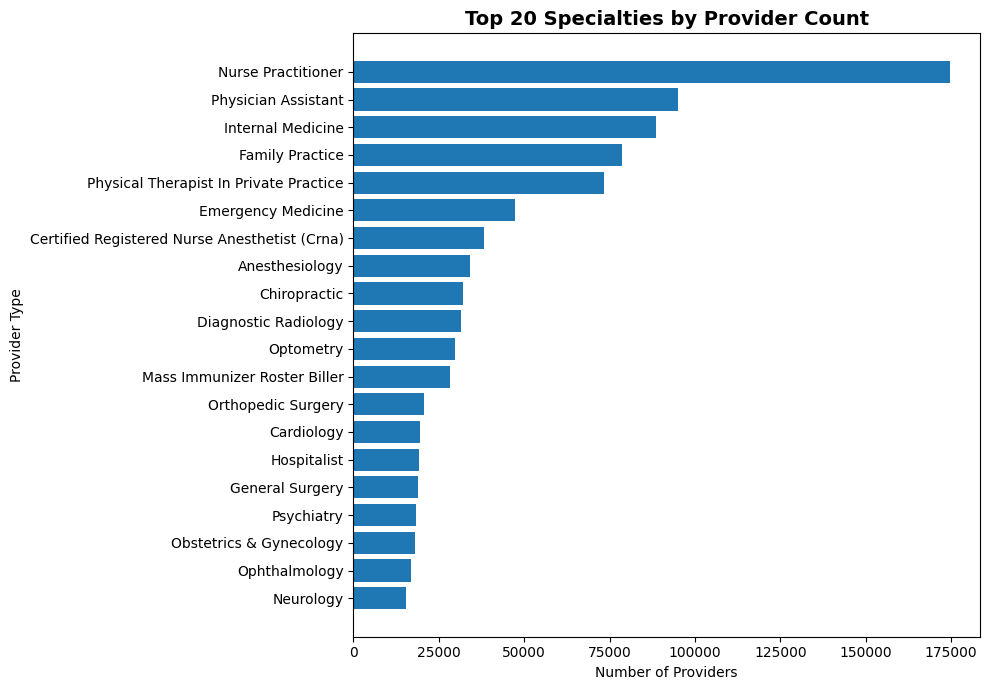

✅ Graph 1 saved


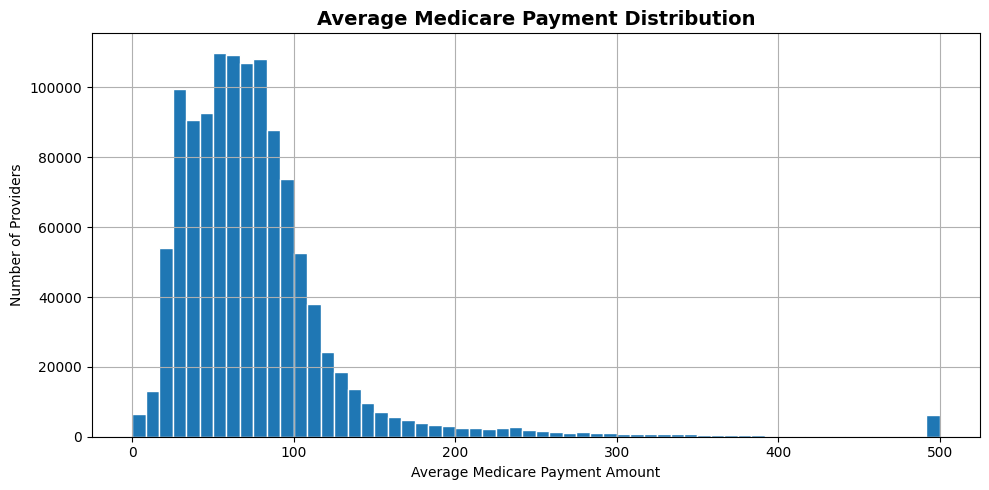

✅ Graph 2 saved


✅ Graph 3 shown


In [42]:
# ==============================================================
# STEP 2.4: Day 2 Graphs — Updated for Your Dataset
# ==============================================================

import os
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

BASE = '/content/drive/MyDrive/fraud_detection'

# Reports folder create karo
os.makedirs(f'{BASE}/reports', exist_ok=True)

# Agar provider_df memory mein already hai to yeh line skip kar sakte ho
# Agar runtime restart hua hai to final CSV reload karo
# provider_df = pd.read_csv(f'{BASE}/data/processed/provider_fraud_features_final.csv', dtype={'Rndrng_NPI': str})


# ==============================================================
# GRAPH 1: Top 20 Provider Types / Specialties
# ==============================================================

top20 = (
    provider_df['Rndrng_Prvdr_Type']
    .value_counts()
    .head(20)
    .reset_index()
)

top20.columns = ['Provider_Type', 'Provider_Count']

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top20['Provider_Type'], top20['Provider_Count'])
ax.set_title('Top 20 Specialties by Provider Count', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Providers')
ax.set_ylabel('Provider Type')
ax.invert_yaxis()

plt.tight_layout()
plt.savefig(f'{BASE}/reports/graph1_top_specialties.png', dpi=150, bbox_inches='tight')
plt.show()

print('✅ Graph 1 saved')


# ==============================================================
# GRAPH 2: Average Medicare Payment Distribution
# ==============================================================

fig2, ax2 = plt.subplots(figsize=(10, 5))

provider_df['Avg_Mdcr_Pymt_Amt'].clip(upper=500).hist(
    bins=60,
    edgecolor='white',
    ax=ax2
)

ax2.set_title('Average Medicare Payment Distribution', fontsize=14, fontweight='bold')
ax2.set_xlabel('Average Medicare Payment Amount')
ax2.set_ylabel('Number of Providers')

plt.tight_layout()
plt.savefig(f'{BASE}/reports/graph2_payment_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print('✅ Graph 2 saved')


# ==============================================================
# GRAPH 3: Interactive Provider Count by State Map
# ==============================================================

state_count = (
    provider_df
    .groupby('Rndrng_Prvdr_State_Abrvtn')
    .size()
    .reset_index(name='count')
)

fig3 = px.choropleth(
    state_count,
    locations='Rndrng_Prvdr_State_Abrvtn',
    locationmode='USA-states',
    color='count',
    scope='usa',
    title='Provider Count by State'
)

fig3.show()

print('✅ Graph 3 shown')

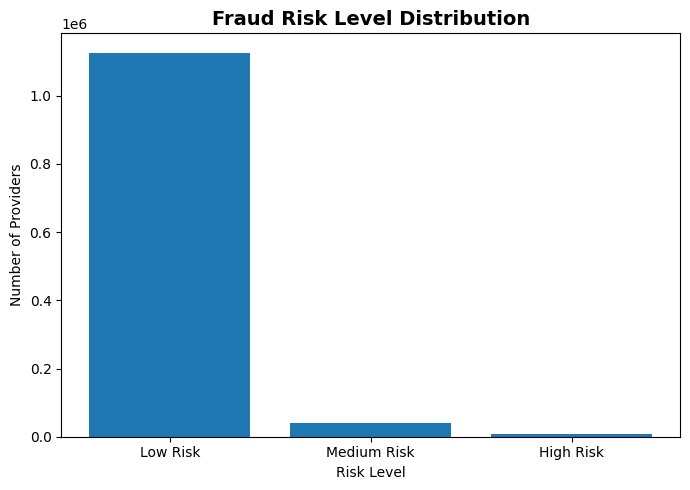

✅ Graph 4 saved


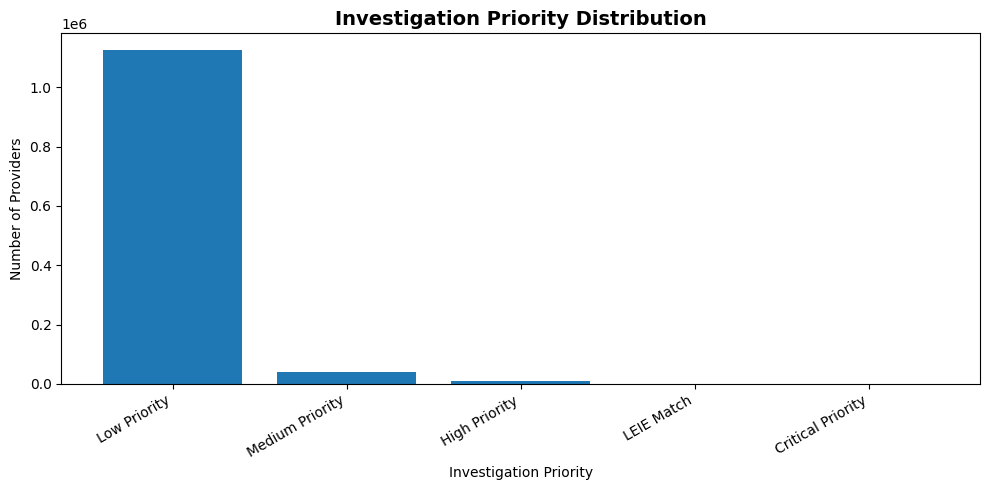

✅ Graph 5 saved


In [43]:
# ==============================================================
# GRAPH 4: Risk Level Distribution
# ==============================================================

risk_counts = provider_df['Risk_Level'].value_counts().reset_index()
risk_counts.columns = ['Risk_Level', 'Count']

fig4, ax4 = plt.subplots(figsize=(7, 5))
ax4.bar(risk_counts['Risk_Level'], risk_counts['Count'])
ax4.set_title('Fraud Risk Level Distribution', fontsize=14, fontweight='bold')
ax4.set_xlabel('Risk Level')
ax4.set_ylabel('Number of Providers')

plt.tight_layout()
plt.savefig(f'{BASE}/reports/graph4_risk_level_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print('✅ Graph 4 saved')


# ==============================================================
# GRAPH 5: Investigation Priority Distribution
# ==============================================================

priority_counts = provider_df['Investigation_Priority'].value_counts().reset_index()
priority_counts.columns = ['Investigation_Priority', 'Count']

fig5, ax5 = plt.subplots(figsize=(10, 5))
ax5.bar(priority_counts['Investigation_Priority'], priority_counts['Count'])
ax5.set_title('Investigation Priority Distribution', fontsize=14, fontweight='bold')
ax5.set_xlabel('Investigation Priority')
ax5.set_ylabel('Number of Providers')
plt.xticks(rotation=30, ha='right')

plt.tight_layout()
plt.savefig(f'{BASE}/reports/graph5_investigation_priority.png', dpi=150, bbox_inches='tight')
plt.show()

print('✅ Graph 5 saved')

In [44]:
# ==============================================================
# Verify saved graph files
# ==============================================================

import os

BASE = '/content/drive/MyDrive/fraud_detection'

report_files = os.listdir(f'{BASE}/reports')

print("✅ Reports folder files:")
for file in report_files:
    print("-", file)

✅ Reports folder files:
- graph1_top_specialties.png
- graph2_payment_distribution.png
- graph4_risk_level_distribution.png
- graph5_investigation_priority.png


In [45]:
# ==============================================================
# DAY 3 — OUTLIER DETECTION MODELS
# Updated for your current provider_fraud_features_final.csv
# ==============================================================

import pandas as pd
import numpy as np
import os
import joblib

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

BASE = '/content/drive/MyDrive/fraud_detection'

# Folders create karo
os.makedirs(f'{BASE}/models', exist_ok=True)
os.makedirs(f'{BASE}/data/processed', exist_ok=True)

# Final provider fraud dataset load karo
model_df = pd.read_csv(
    f'{BASE}/data/processed/provider_fraud_features_final.csv',
    dtype={'Rndrng_NPI': str},
    low_memory=False
)

print("✅ Final fraud dataset loaded")
print("Shape:", model_df.shape)

✅ Final fraud dataset loaded
Shape: (1175281, 53)


In [46]:
# ==============================================================
# STEP 3.1: Z-Score Outlier Detection
# ==============================================================

zscore_cols = [
    'Payment_Per_Bene_Zscore',
    'Services_Per_Bene_Zscore',
    'Payment_Per_Service_Zscore',
    'Charge_To_Payment_Ratio_Zscore',
    'Unique_HCPCS_Count_Zscore'
]

# Check columns exist
missing_cols = [col for col in zscore_cols if col not in model_df.columns]

if missing_cols:
    print("❌ Missing z-score columns:")
    print(missing_cols)
else:
    # Agar kisi bhi z-score ka absolute value 3 se zyada hai to outlier
    model_df['outlier_zscore'] = (
        model_df[zscore_cols].abs().max(axis=1) > 3
    ).astype(int)

    print(f'✅ Z-score outliers found: {model_df["outlier_zscore"].sum():,}')
    print(f'   Total providers: {len(model_df):,}')

✅ Z-score outliers found: 61,135
   Total providers: 1,175,281


In [47]:
# ==============================================================
# STEP 3.2: Isolation Forest Outlier Model
# ==============================================================

features = [
    'Tot_Benes',
    'Tot_Srvcs',
    'Tot_Mdcr_Pymt_Amt',
    'Avg_Sbmtd_Chrg',
    'Avg_Mdcr_Alowd_Amt',
    'Avg_Mdcr_Pymt_Amt',
    'Unique_HCPCS_Count',
    'Payment_Per_Bene',
    'Services_Per_Bene',
    'Payment_Per_Service',
    'Charge_To_Payment_Ratio'
]

# Check missing feature columns
missing_features = [col for col in features if col not in model_df.columns]

if missing_features:
    print("❌ Missing feature columns:")
    print(missing_features)
else:
    X = model_df[features].replace([np.inf, -np.inf], np.nan).fillna(0)

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    print("Isolation Forest train ho raha hai...")

    iso = IsolationForest(
        contamination=0.05,
        random_state=42,
        n_estimators=200
    )

    model_df['iso_flag'] = iso.fit_predict(X_scaled)

    # -1 means anomaly
    model_df['iso_flag'] = (model_df['iso_flag'] == -1).astype(int)

    # Combined model risk
    model_df['combined_model_risk'] = (
        (model_df['outlier_zscore'] == 1) |
        (model_df['iso_flag'] == 1)
    ).astype(int)

    # Model aur scaler save karo
    joblib.dump(iso, f'{BASE}/models/isolation_forest.pkl')
    joblib.dump(scaler, f'{BASE}/models/scaler.pkl')

    # Updated dataset save karo
    model_df.to_csv(
        f'{BASE}/data/processed/outlier_flags.csv',
        index=False
    )

    print(f'✅ Isolation Forest anomalies: {model_df["iso_flag"].sum():,}')
    print(f'✅ Combined model-risk providers: {model_df["combined_model_risk"].sum():,}')
    print('✅ Models saved in Google Drive')
    print('Saved file:', f'{BASE}/data/processed/outlier_flags.csv')

Isolation Forest train ho raha hai...
✅ Isolation Forest anomalies: 58,764
✅ Combined model-risk providers: 102,685
✅ Models saved in Google Drive
Saved file: /content/drive/MyDrive/fraud_detection/data/processed/outlier_flags.csv


In [1]:
# ==============================================================
# STEP 3.3: Day 3 Graphs — Updated
# ==============================================================

import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import os

BASE = '/content/drive/MyDrive/fraud_detection'

os.makedirs(f'{BASE}/reports', exist_ok=True)

df = pd.read_csv(
    f'{BASE}/data/processed/outlier_flags.csv',
    dtype={'Rndrng_NPI': str},
    low_memory=False
)

print("✅ Outlier flags file loaded")
print(df.shape)

✅ Outlier flags file loaded
(1175281, 56)


In [2]:
# ==============================================================
# GRAPH 4: Services vs Average Payment — Outliers Highlighted
# ==============================================================

sample = df.sample(min(5000, len(df)), random_state=42)

fig = px.scatter(
    sample,
    x='Tot_Srvcs',
    y='Avg_Mdcr_Pymt_Amt',
    color='combined_model_risk',
    title='Services vs Average Medicare Payment — Outliers Highlighted',
    opacity=0.6,
    labels={
        'Tot_Srvcs': 'Total Services',
        'Avg_Mdcr_Pymt_Amt': 'Average Medicare Payment',
        'combined_model_risk': 'Model Risk Flag'
    }
)

fig.show()

print('✅ Graph 4 shown')

✅ Graph 4 shown


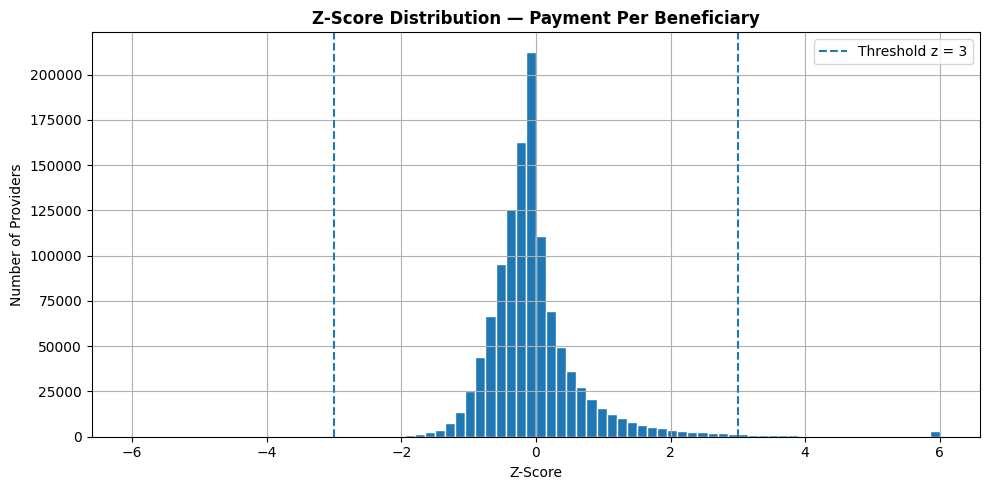

✅ Graph 5 saved


In [3]:
# ==============================================================
# GRAPH 5: Z-Score Distribution
# ==============================================================

fig2, ax = plt.subplots(figsize=(10, 5))

df['Payment_Per_Bene_Zscore'].clip(-6, 6).hist(
    bins=80,
    edgecolor='white',
    ax=ax
)

ax.axvline(3, linestyle='--', label='Threshold z = 3')
ax.axvline(-3, linestyle='--')

ax.set_title('Z-Score Distribution — Payment Per Beneficiary', fontweight='bold')
ax.set_xlabel('Z-Score')
ax.set_ylabel('Number of Providers')
ax.legend()

plt.tight_layout()
plt.savefig(f'{BASE}/reports/graph5_zscore_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print('✅ Graph 5 saved')

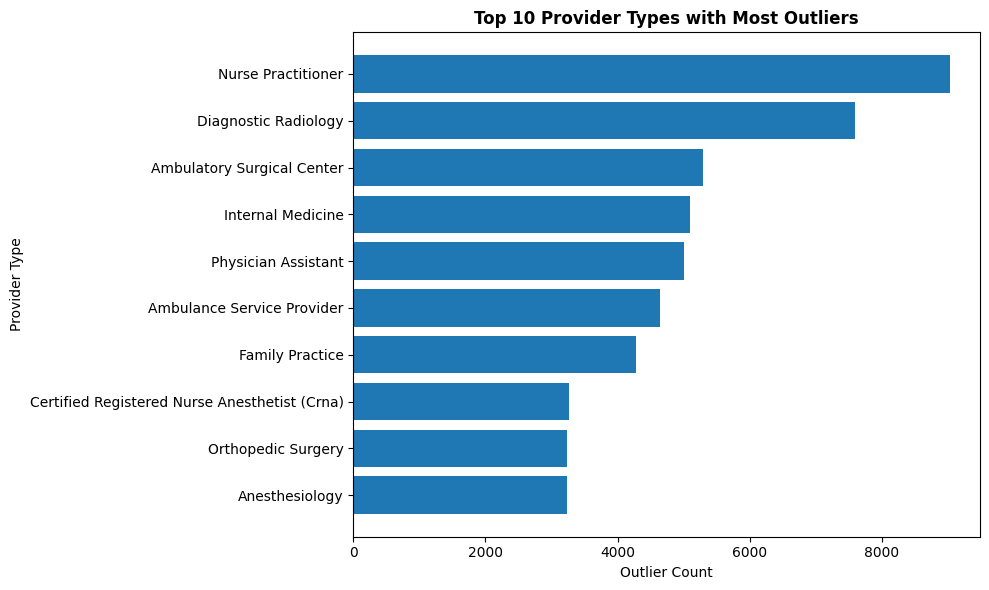

✅ Graph 6 saved

Top 3 outlier provider types:
            Rndrng_Prvdr_Type  outlier_count
0          Nurse Practitioner           9033
1        Diagnostic Radiology           7596
2  Ambulatory Surgical Center           5297


In [4]:
# ==============================================================
# GRAPH 6: Top 10 Provider Types with Most Outliers
# ==============================================================

top_spec = (
    df[df['combined_model_risk'] == 1]
    .groupby('Rndrng_Prvdr_Type')
    .size()
    .nlargest(10)
    .reset_index(name='outlier_count')
)

fig3, ax3 = plt.subplots(figsize=(10, 6))

ax3.barh(top_spec['Rndrng_Prvdr_Type'], top_spec['outlier_count'])
ax3.set_title('Top 10 Provider Types with Most Outliers', fontweight='bold')
ax3.set_xlabel('Outlier Count')
ax3.set_ylabel('Provider Type')
ax3.invert_yaxis()

plt.tight_layout()
plt.savefig(f'{BASE}/reports/graph6_top_outlier_provider_types.png', dpi=150, bbox_inches='tight')
plt.show()

print('✅ Graph 6 saved')

print("\nTop 3 outlier provider types:")
print(top_spec.head(3))

In [5]:
# ==============================================================
# DAY 4 — UPCODING + DUPLICATE CLASSIFIER
# STEP 4.1: Upcoding Detection
# ==============================================================

import pandas as pd
import numpy as np
import os

BASE = '/content/drive/MyDrive/fraud_detection'

# Pehle cleaned service-level file try karo
providers_clean_path = f'{BASE}/data/processed/providers_clean.csv'

# Agar providers_clean.csv nahi hai, to original CMS file use karo
cms_path = '/content/drive/MyDrive/MUP_PHY_R25_P05_V20_D23_Prov_Svc.csv'

if os.path.exists(providers_clean_path):
    df_raw = pd.read_csv(
        providers_clean_path,
        dtype={'Rndrng_NPI': str, 'HCPCS_Cd': str},
        low_memory=False
    )
    print("✅ providers_clean.csv loaded")
else:
    df_raw = pd.read_csv(
        cms_path,
        dtype={'Rndrng_NPI': str, 'HCPCS_Cd': str},
        low_memory=False
    )
    print("✅ Original CMS file loaded")

print("Shape:", df_raw.shape)
print("Columns:", df_raw.columns.tolist()[:10])

✅ providers_clean.csv loaded
Shape: (2927222, 30)
Columns: ['Rndrng_NPI', 'Rndrng_Prvdr_Last_Org_Name', 'Rndrng_Prvdr_First_Name', 'Rndrng_Prvdr_MI', 'Rndrng_Prvdr_Crdntls', 'Rndrng_Prvdr_Ent_Cd', 'Rndrng_Prvdr_St1', 'Rndrng_Prvdr_St2', 'Rndrng_Prvdr_City', 'Rndrng_Prvdr_State_Abrvtn']


In [6]:
# ==============================================================
# E&M codes filter
# ==============================================================

em_codes = ['99211', '99212', '99213', '99214', '99215']

df_raw['HCPCS_Cd'] = df_raw['HCPCS_Cd'].astype(str).str.strip()

em_df = df_raw[df_raw['HCPCS_Cd'].isin(em_codes)].copy()

if len(em_df) == 0:
    print('⚠️ E&M codes nahi mile')
    print('Available HCPCS examples:')
    print(df_raw['HCPCS_Cd'].head(20).tolist())
else:
    print(f'✅ E&M records found: {len(em_df):,}')

    weight_map = {
        '99211': 1,
        '99212': 2,
        '99213': 3,
        '99214': 4,
        '99215': 5
    }

    em_df['weight'] = em_df['HCPCS_Cd'].map(weight_map)

    em_df['Tot_Srvcs'] = pd.to_numeric(em_df['Tot_Srvcs'], errors='coerce').fillna(0)

    em_summary = em_df.groupby([
        'Rndrng_NPI',
        'Rndrng_Prvdr_Type'
    ]).apply(
        lambda x: np.average(x['weight'], weights=x['Tot_Srvcs'])
        if x['Tot_Srvcs'].sum() > 0 else np.nan
    ).reset_index(name='avg_em_complexity')

    spec_avg = em_summary.groupby('Rndrng_Prvdr_Type')['avg_em_complexity'].agg(
        ['mean', 'std']
    ).reset_index()

    em_summary = em_summary.merge(spec_avg, on='Rndrng_Prvdr_Type', how='left')

    em_summary['em_z_score'] = (
        (em_summary['avg_em_complexity'] - em_summary['mean']) /
        em_summary['std'].replace(0, 1)
    )

    em_summary['em_z_score'] = em_summary['em_z_score'].replace(
        [np.inf, -np.inf],
        np.nan
    ).fillna(0)

    em_summary['upcoding_flag'] = (em_summary['em_z_score'] > 2).astype(int)

    os.makedirs(f'{BASE}/data/processed', exist_ok=True)

    em_summary.to_csv(
        f'{BASE}/data/processed/upcoding_scores.csv',
        index=False
    )

    print(f'✅ Upcoding flags: {em_summary["upcoding_flag"].sum():,} providers')
    print("✅ upcoding_scores.csv saved")

✅ E&M records found: 376,968


/tmp/ipykernel_58954/3110659390.py:33: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



✅ Upcoding flags: 4,860 providers
✅ upcoding_scores.csv saved


In [7]:
# ==============================================================
# STEP 4.2: Duplicate Classifier — Updated + Safer Sample Version
# ==============================================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import joblib
import numpy as np
import pandas as pd
import os

BASE = '/content/drive/MyDrive/fraud_detection'

# Agar df_raw already loaded hai, use karo
# Agar runtime restart hua hai, original CMS file reload karo
if 'df_raw' not in globals():
    cms_path = '/content/drive/MyDrive/MUP_PHY_R25_P05_V20_D23_Prov_Svc.csv'
    df_raw = pd.read_csv(
        cms_path,
        dtype={'Rndrng_NPI': str, 'HCPCS_Cd': str},
        low_memory=False
    )

# Required numeric columns
dup_cols = [
    'Tot_Srvcs',
    'Avg_Mdcr_Alowd_Amt',
    'Avg_Sbmtd_Chrg',
    'Tot_Benes'
]

for col in dup_cols:
    df_raw[col] = pd.to_numeric(df_raw[col], errors='coerce').fillna(0)

# Large file hai, is liye sample le rahe hain
sample_size = min(300000, len(df_raw))

claims = df_raw.sample(sample_size, random_state=42).copy()

n_dupes = int(len(claims) * 0.10)

dupes = claims.sample(n_dupes, random_state=42).copy()

# Slight changes to simulate near-duplicate claims
dupes['Avg_Sbmtd_Chrg'] *= np.random.uniform(0.98, 1.02, n_dupes)
dupes['Tot_Srvcs'] += np.random.randint(-1, 2, n_dupes)

# Negative services avoid karo
dupes['Tot_Srvcs'] = dupes['Tot_Srvcs'].clip(lower=0)

claims['is_duplicate'] = 0
dupes['is_duplicate'] = 1

all_claims = pd.concat([claims, dupes], ignore_index=True)

features = [
    'Tot_Srvcs',
    'Avg_Mdcr_Alowd_Amt',
    'Avg_Sbmtd_Chrg',
    'Tot_Benes'
]

X = all_claims[features].fillna(0)
y = all_claims['is_duplicate']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('Random Forest train ho raha hai...')

clf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print('\nClassification Report:')
print(classification_report(y_test, y_pred))

print('\nConfusion Matrix:')
print(confusion_matrix(y_test, y_pred))

os.makedirs(f'{BASE}/models', exist_ok=True)

joblib.dump(clf, f'{BASE}/models/dup_classifier.pkl')

print('✅ Duplicate classifier saved')
print(f'Saved at: {BASE}/models/dup_classifier.pkl')

Random Forest train ho raha hai...

Classification Report:
              precision    recall  f1-score   support

           0       0.92      1.00      0.96     60000
           1       0.84      0.07      0.13      6000

    accuracy                           0.91     66000
   macro avg       0.88      0.54      0.54     66000
weighted avg       0.91      0.91      0.88     66000


Confusion Matrix:
[[59919    81]
 [ 5561   439]]
✅ Duplicate classifier saved
Saved at: /content/drive/MyDrive/fraud_detection/models/dup_classifier.pkl


In [8]:
# ==============================================================
# STEP 4.2B: Improved Duplicate Classifier
# ==============================================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import joblib
import numpy as np
import pandas as pd
import os

BASE = '/content/drive/MyDrive/fraud_detection'

# Required numeric columns
dup_cols = [
    'Tot_Srvcs',
    'Avg_Mdcr_Alowd_Amt',
    'Avg_Sbmtd_Chrg',
    'Tot_Benes'
]

for col in dup_cols:
    df_raw[col] = pd.to_numeric(df_raw[col], errors='coerce').fillna(0)

# Sample for speed
sample_size = min(300000, len(df_raw))
claims = df_raw.sample(sample_size, random_state=42).copy()

# Create synthetic duplicate examples
n_dupes = int(len(claims) * 0.10)
dupes = claims.sample(n_dupes, random_state=42).copy()

dupes['Avg_Sbmtd_Chrg'] *= np.random.uniform(0.98, 1.02, n_dupes)
dupes['Avg_Mdcr_Alowd_Amt'] *= np.random.uniform(0.98, 1.02, n_dupes)
dupes['Tot_Srvcs'] += np.random.randint(-1, 2, n_dupes)
dupes['Tot_Benes'] += np.random.randint(-1, 2, n_dupes)

dupes['Tot_Srvcs'] = dupes['Tot_Srvcs'].clip(lower=0)
dupes['Tot_Benes'] = dupes['Tot_Benes'].clip(lower=0)

claims['is_duplicate'] = 0
dupes['is_duplicate'] = 1

all_claims = pd.concat([claims, dupes], ignore_index=True)

features = [
    'Tot_Srvcs',
    'Avg_Mdcr_Alowd_Amt',
    'Avg_Sbmtd_Chrg',
    'Tot_Benes'
]

X = all_claims[features].fillna(0)
y = all_claims['is_duplicate']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('Improved Random Forest train ho raha hai...')

clf2 = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced',
    max_depth=20
)

clf2.fit(X_train, y_train)

# Instead of default 0.50 threshold, use lower threshold to catch more duplicates
probs = clf2.predict_proba(X_test)[:, 1]

threshold = 0.25
y_pred = (probs >= threshold).astype(int)

print('\nClassification Report with threshold =', threshold)
print(classification_report(y_test, y_pred))

print('\nConfusion Matrix:')
print(confusion_matrix(y_test, y_pred))

joblib.dump(clf2, f'{BASE}/models/dup_classifier_improved.pkl')

print('✅ Improved duplicate classifier saved')
print(f'Saved at: {BASE}/models/dup_classifier_improved.pkl')

Improved Random Forest train ho raha hai...

Classification Report with threshold = 0.25
              precision    recall  f1-score   support

           0       0.96      0.10      0.18     60000
           1       0.10      0.96      0.18      6000

    accuracy                           0.18     66000
   macro avg       0.53      0.53      0.18     66000
weighted avg       0.88      0.18      0.18     66000


Confusion Matrix:
[[ 6068 53932]
 [  229  5771]]
✅ Improved duplicate classifier saved
Saved at: /content/drive/MyDrive/fraud_detection/models/dup_classifier_improved.pkl


In [9]:
# ==============================================================
# STEP 4.2C: Threshold Tuning for Duplicate Classifier
# ==============================================================

from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
import pandas as pd
import numpy as np

thresholds = [0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70, 0.75]

results = []

for th in thresholds:
    y_pred_th = (probs >= th).astype(int)

    results.append({
        'threshold': th,
        'accuracy': accuracy_score(y_test, y_pred_th),
        'precision_duplicate': precision_score(y_test, y_pred_th, zero_division=0),
        'recall_duplicate': recall_score(y_test, y_pred_th, zero_division=0),
        'f1_duplicate': f1_score(y_test, y_pred_th, zero_division=0)
    })

threshold_results = pd.DataFrame(results)

print("✅ Threshold tuning results:")
display(threshold_results)

best_row = threshold_results.sort_values('f1_duplicate', ascending=False).iloc[0]

print("\n✅ Best threshold based on duplicate F1-score:")
print(best_row)

✅ Threshold tuning results:


,threshold,accuracy,precision_duplicate,recall_duplicate,f1_duplicate
0,0.25,0.179379,0.096662,0.961833,0.175669
1,0.30,0.211939,0.098555,0.941333,0.178429
2,0.35,0.238515,0.099519,0.916500,0.179542
3,0.40,0.275333,0.101486,0.887667,0.182148
4,0.45,0.331242,0.104197,0.836667,0.185315
5,0.50,0.827697,0.201688,0.302667,0.242069
6,0.55,0.913455,0.699446,0.084167,0.150253
7,0.60,0.914879,0.920705,0.069667,0.129532
8,0.65,0.915061,0.990050,0.066333,0.124336
9,0.70,0.914939,1.000000,0.064333,0.120889



✅ Best threshold based on duplicate F1-score:
threshold              0.500000
accuracy               0.827697
precision_duplicate    0.201688
recall_duplicate       0.302667
f1_duplicate           0.242069
Name: 5, dtype: float64


In [10]:
# ==============================================================
# STEP 4.2D: Save Best Threshold Info
# ==============================================================

best_threshold = float(best_row['threshold'])

threshold_info = pd.DataFrame([{
    'best_threshold': best_threshold,
    'accuracy': best_row['accuracy'],
    'precision_duplicate': best_row['precision_duplicate'],
    'recall_duplicate': best_row['recall_duplicate'],
    'f1_duplicate': best_row['f1_duplicate']
}])

threshold_info.to_csv(
    f'{BASE}/models/duplicate_classifier_threshold_info.csv',
    index=False
)

print("✅ Best threshold saved")
print("Best threshold:", best_threshold)

✅ Best threshold saved
Best threshold: 0.5


In [11]:
# ==============================================================
# STEP 4.2E: Final Duplicate Classifier Evaluation Save
# ==============================================================

from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd

best_threshold = 0.5

y_pred_final = (probs >= best_threshold).astype(int)

print("Final Classification Report:")
print(classification_report(y_test, y_pred_final))

print("Final Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_final))

# Save classification report as CSV
report_dict = classification_report(y_test, y_pred_final, output_dict=True)
report_df = pd.DataFrame(report_dict).transpose()

report_df.to_csv(
    f'{BASE}/reports/duplicate_classifier_final_report.csv',
    index=True
)

print("✅ Final duplicate classifier report saved")
print(f"Saved at: {BASE}/reports/duplicate_classifier_final_report.csv")

Final Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.88      0.90     60000
           1       0.20      0.30      0.24      6000

    accuracy                           0.83     66000
   macro avg       0.56      0.59      0.57     66000
weighted avg       0.86      0.83      0.84     66000

Final Confusion Matrix:
[[52812  7188]
 [ 4184  1816]]
✅ Final duplicate classifier report saved
Saved at: /content/drive/MyDrive/fraud_detection/reports/duplicate_classifier_final_report.csv


In [16]:
# ==============================================================
# GRAPH 8: E&M Code Distribution
# ==============================================================

import os
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

BASE = '/content/drive/MyDrive/fraud_detection'
os.makedirs(f'{BASE}/reports', exist_ok=True)

if 'em_df' in globals() and len(em_df) > 0:
    em_counts = (
        em_df.groupby('HCPCS_Cd')['Tot_Srvcs']
        .sum()
        .reset_index()
    )

    fig = px.pie(
        em_counts,
        names='HCPCS_Cd',
        values='Tot_Srvcs',
        title='E&M Code Distribution (All Providers)'
    )

    fig.show()

    fig.write_html(f'{BASE}/reports/graph8_em_code_distribution.html')

    print('✅ Graph 8 shown and saved as HTML')
else:
    print("⚠️ em_df memory mein nahi mila. Upcoding cell dobara run karo.")

✅ Graph 8 shown and saved as HTML


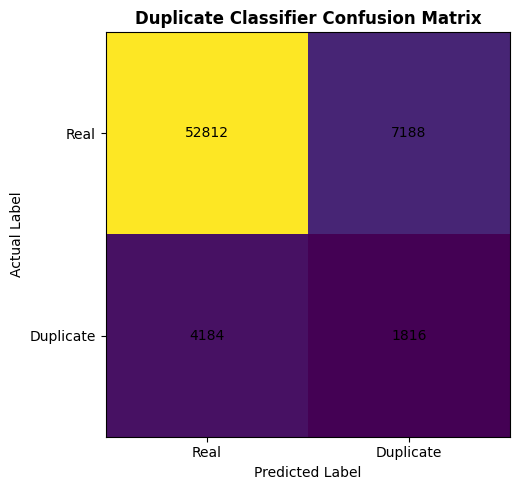

✅ Graph 10 saved
Confusion Matrix:
[[52812  7188]
 [ 4184  1816]]


In [13]:
# ==============================================================
# GRAPH 10: Duplicate Classifier Confusion Matrix
# ==============================================================

from sklearn.metrics import confusion_matrix
import numpy as np

# Best threshold already 0.5 hai
best_threshold = 0.5

# Final prediction
y_pred_final = (probs >= best_threshold).astype(int)

cm = confusion_matrix(y_test, y_pred_final)

fig2, ax = plt.subplots(figsize=(6, 5))

im = ax.imshow(cm)

ax.set_title('Duplicate Classifier Confusion Matrix', fontweight='bold')
ax.set_xlabel('Predicted Label')
ax.set_ylabel('Actual Label')

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Real', 'Duplicate'])
ax.set_yticklabels(['Real', 'Duplicate'])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha='center', va='center')

plt.tight_layout()
plt.savefig(f'{BASE}/reports/graph10_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print('✅ Graph 10 saved')
print("Confusion Matrix:")
print(cm)

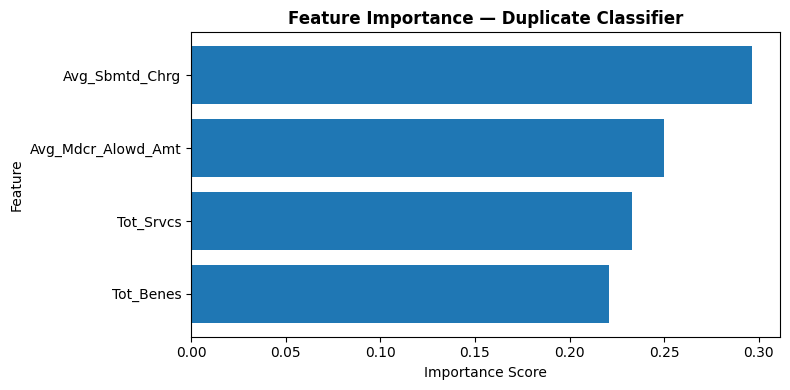

✅ Graph 11 saved


In [14]:
# ==============================================================
# GRAPH 11: Feature Importance — Duplicate Classifier
# ==============================================================

import pandas as pd

# clf2 = improved classifier
# features = duplicate classifier input features

imp = pd.Series(
    clf2.feature_importances_,
    index=features
).sort_values(ascending=True)

fig3, ax3 = plt.subplots(figsize=(8, 4))

ax3.barh(imp.index, imp.values)
ax3.set_title('Feature Importance — Duplicate Classifier', fontweight='bold')
ax3.set_xlabel('Importance Score')
ax3.set_ylabel('Feature')

plt.tight_layout()
plt.savefig(f'{BASE}/reports/graph11_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('✅ Graph 11 saved')

In [17]:
# ==============================================================
# DAY 5 — LEIE CROSS-REFERENCE FINAL CHECK
# ==============================================================

import pandas as pd
import numpy as np
import os
from datetime import datetime

BASE = '/content/drive/MyDrive/fraud_detection'

# Load LEIE
leie = pd.read_csv(
    f'{BASE}/data/raw/leie_exclusions.csv',
    dtype={'NPI': str},
    low_memory=False
)

leie.columns = leie.columns.str.upper().str.strip()

print("✅ LEIE loaded")
print("LEIE columns:", leie.columns.tolist())

# Clean NPI
leie['NPI'] = (
    leie['NPI']
    .fillna('')
    .astype(str)
    .str.replace('.0', '', regex=False)
    .str.strip()
)

leie['NPI'] = leie['NPI'].replace(['', '0', 'nan', 'None'], np.nan)

# Parse dates safely
leie['EXCLDATE'] = pd.to_datetime(leie['EXCLDATE'], format='%Y%m%d', errors='coerce')
leie['REINDATE'] = pd.to_datetime(leie['REINDATE'], format='%Y%m%d', errors='coerce')

# Active exclusion = no reinstatement date
leie['still_excluded'] = leie['REINDATE'].isna()

print(f"Total LEIE records: {len(leie):,}")
print(f"Valid NPI records: {leie['NPI'].notna().sum():,}")
print(f"Still excluded: {leie['still_excluded'].sum():,}")
print(f"Reinstated: {(~leie['still_excluded']).sum():,}")

✅ LEIE loaded
LEIE columns: ['LASTNAME', 'FIRSTNAME', 'MIDNAME', 'BUSNAME', 'GENERAL', 'SPECIALTY', 'UPIN', 'NPI', 'DOB', 'ADDRESS', 'CITY', 'STATE', 'ZIP', 'EXCLTYPE', 'EXCLDATE', 'REINDATE', 'WAIVERDATE', 'WVRSTATE']
Total LEIE records: 83,256
Valid NPI records: 83,256
Still excluded: 83,256
Reinstated: 0


In [19]:
# ==============================================================
# FIX: Correct LEIE NPI Cleaning
# ==============================================================

import numpy as np
import pandas as pd

leie['NPI_clean'] = (
    leie['NPI']
    .astype(str)
    .str.replace('.0', '', regex=False)
    .str.strip()
)

# Invalid values remove
leie['NPI_clean'] = leie['NPI_clean'].replace(
    ['', 'nan', 'None', 'NONE', '0', '0000000000'],
    np.nan
)

# Sirf proper 10-digit NPI keep karo
leie.loc[
    ~leie['NPI_clean'].astype(str).str.match(r'^\d{10}$', na=False),
    'NPI_clean'
] = np.nan

print("Total LEIE records:", len(leie))
print("Valid NPI records:", leie['NPI_clean'].notna().sum())
print("Invalid / missing NPI records:", leie['NPI_clean'].isna().sum())

Total LEIE records: 83256
Valid NPI records: 8608
Invalid / missing NPI records: 74648


In [21]:
# ==============================================================
# STEP 5.2 FIXED: Active LEIE Match with Final Provider Dataset
# ==============================================================

from datetime import datetime
import pandas as pd
import os

BASE = '/content/drive/MyDrive/fraud_detection'

providers = pd.read_csv(
    f'{BASE}/data/processed/outlier_flags.csv',
    dtype={'Rndrng_NPI': str},
    low_memory=False
)

providers['Rndrng_NPI'] = providers['Rndrng_NPI'].astype(str).str.strip()

active_leie = leie[
    (leie['still_excluded'] == True) &
    (leie['NPI_clean'].notna())
][[
    'NPI_clean',
    'LASTNAME',
    'FIRSTNAME',
    'BUSNAME',
    'EXCLTYPE',
    'EXCLDATE',
    'REINDATE',
    'STATE'
]].drop_duplicates(subset=['NPI_clean'])

matched_active = providers.merge(
    active_leie,
    left_on='Rndrng_NPI',
    right_on='NPI_clean',
    how='inner'
)

ts = datetime.now().strftime('%Y%m%d')

matched_active.to_csv(
    f'{BASE}/data/processed/active_leie_matches_{ts}.csv',
    index=False
)

print(f"✅ Active LEIE matched providers: {len(matched_active):,}")

if len(matched_active) > 0:
    display_cols = [
        'Rndrng_NPI',
        'Provider_Name',
        'Rndrng_Prvdr_Type',
        'Peer_Group',
        'Fraud_Risk_Score',
        'Risk_Level',
        'Investigation_Priority'
    ]
    if 'EXCLTYPE' in matched_active.columns:
        display_cols.append('EXCLTYPE')
    if 'EXCLDATE' in matched_active.columns:
        display_cols.append('EXCLDATE')

    display(matched_active[display_cols].head(20))
else:
    print("✅ No active LEIE excluded provider found in CMS provider data")

✅ Active LEIE matched providers: 196


,Rndrng_NPI,Provider_Name,Rndrng_Prvdr_Type,Peer_Group,Fraud_Risk_Score,Risk_Level,Investigation_Priority
0,1003078684,Hayriye Gok,Family Practice,Family Practice_FL,4.068330,Low Risk,LEIE Match
1,1003242314,Christopher Earle,Nurse Practitioner,Nurse Practitioner_AZ,0.487045,Low Risk,LEIE Match
2,1003312018,Jahanzaib Idrees,Preventive Medicine,Preventive Medicine_CT,2.721104,Low Risk,LEIE Match
3,1003952185,Terry Boatman,Certified Registered Nurse Anesthetist (Crna),Certified Registered Nurse Anesthetist (Crna)_TX,3.441861,Low Risk,LEIE Match
4,1013090877,Joel Klein,Family Practice,Family Practice_OR,1.805552,Low Risk,LEIE Match
5,1013266550,Lauren Sword,Chiropractic,Chiropractic_MO,0.000000,Low Risk,LEIE Match
6,1023188703,Norris Lee,Otolaryngology,Otolaryngology_ME,3.911506,Low Risk,LEIE Match
7,1023195716,Robine Elias,Chiropractic,Chiropractic_PA,0.000000,Low Risk,LEIE Match
8,1033111000,Oliver Jenkins,Otolaryngology,Otolaryngology_GA,1.142912,Low Risk,LEIE Match
9,1033136569,Carrie Musselman,Chiropractic,Chiropractic_IL,1.762621,Low Risk,LEIE Match


In [22]:
# ==============================================================
# STEP 5.3: LEIE Graphs
# ==============================================================

import matplotlib.pyplot as plt
import plotly.express as px

os.makedirs(f'{BASE}/reports', exist_ok=True)

In [23]:
# ==============================================================
# GRAPH 12: LEIE Exclusions per Year
# ==============================================================

import plotly.express as px
import os

BASE = '/content/drive/MyDrive/fraud_detection'
os.makedirs(f'{BASE}/reports', exist_ok=True)

leie['year'] = leie['EXCLDATE'].dt.year

yearly = (
    leie[leie['year'].between(2000, 2026)]
    .groupby('year')
    .size()
    .reset_index(name='count')
)

fig = px.line(
    yearly,
    x='year',
    y='count',
    markers=True,
    title='LEIE Exclusions per Year'
)

fig.show()

fig.write_html(f'{BASE}/reports/graph12_leie_exclusions_per_year.html')

print("✅ Graph 12 shown and saved as HTML")

✅ Graph 12 shown and saved as HTML


,EXCLTYPE,count
0,1128b4,33136
1,1128a1,25760
2,1128a2,8073
3,1128a3,5826
4,1128a4,3551
5,1128b14,2167
6,1128b8,1497
7,1128b1,936
8,1128b5,803
9,1128b7,735


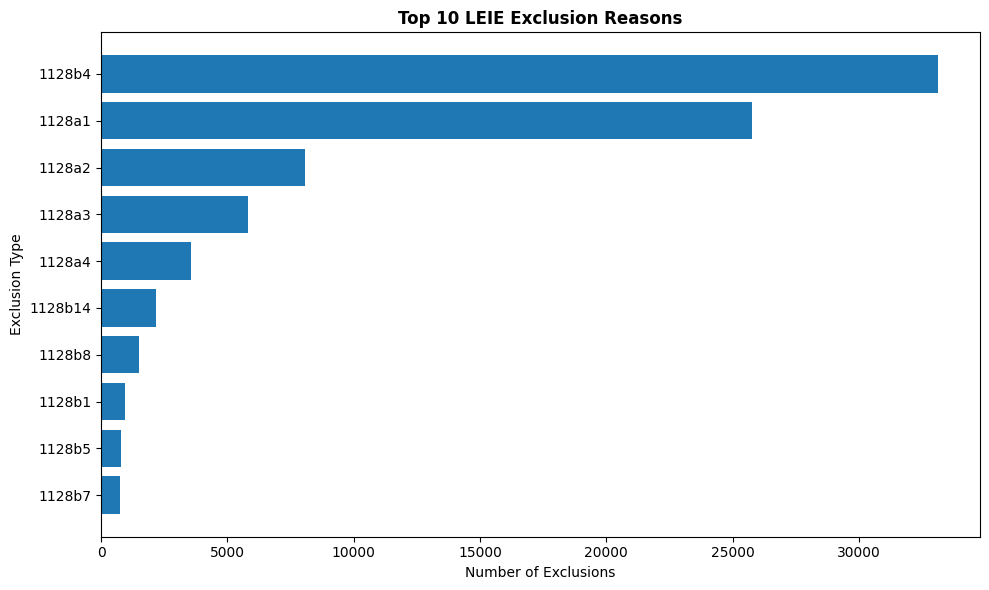

✅ Graph 13 saved


In [24]:
# ==============================================================
# GRAPH 13: Top 10 LEIE Exclusion Reasons
# ==============================================================

import matplotlib.pyplot as plt

top_reasons = (
    leie['EXCLTYPE']
    .value_counts()
    .head(10)
    .reset_index()
)

top_reasons.columns = ['EXCLTYPE', 'count']

display(top_reasons)

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(top_reasons['EXCLTYPE'], top_reasons['count'])
ax.set_title('Top 10 LEIE Exclusion Reasons', fontweight='bold')
ax.set_xlabel('Number of Exclusions')
ax.set_ylabel('Exclusion Type')
ax.invert_yaxis()

plt.tight_layout()

plt.savefig(
    f'{BASE}/reports/graph13_exclusion_reasons.png',
    dpi=200,
    bbox_inches='tight'
)

plt.show()

print("✅ Graph 13 saved")

In [25]:
# ==============================================================
# STEP 5.4: LEIE Match Summary
# ==============================================================

print("LEIE matched providers:", len(matched_active))

print("\nRisk level among LEIE matches:")
print(matched_active['Risk_Level'].value_counts())

print("\nInvestigation priority among LEIE matches:")
print(matched_active['Investigation_Priority'].value_counts())

leie_summary = matched_active.groupby([
    'Risk_Level',
    'Investigation_Priority'
]).size().reset_index(name='count')

display(leie_summary)

leie_summary.to_csv(
    f'{BASE}/reports/leie_match_summary.csv',
    index=False
)

print("✅ LEIE match summary saved")

LEIE matched providers: 196

Risk level among LEIE matches:
Risk_Level
Low Risk       176
Medium Risk     15
High Risk        5
Name: count, dtype: int64

Investigation priority among LEIE matches:
Investigation_Priority
LEIE Match           191
Critical Priority      5
Name: count, dtype: int64


,Risk_Level,Investigation_Priority,count
0,High Risk,Critical Priority,5
1,Low Risk,LEIE Match,176
2,Medium Risk,LEIE Match,15


✅ LEIE match summary saved


In [26]:
# ==============================================================
# DAY 6 — REPORTS + DELIVERABLES
# STEP 6.1: Final Summary Report
# ==============================================================

import pandas as pd
import os
import glob

BASE = '/content/drive/MyDrive/fraud_detection'

final_df = pd.read_csv(
    f'{BASE}/data/processed/outlier_flags.csv',
    dtype={'Rndrng_NPI': str},
    low_memory=False
)

upc = pd.read_csv(f'{BASE}/data/processed/upcoding_scores.csv')

# Latest active LEIE match file find karo
leie_files = glob.glob(f'{BASE}/data/processed/active_leie_matches_*.csv')

if len(leie_files) > 0:
    latest_leie_file = sorted(leie_files)[-1]
    leie_matches = pd.read_csv(latest_leie_file, dtype={'Rndrng_NPI': str})
else:
    latest_leie_file = None
    leie_matches = pd.DataFrame()

print('=' * 60)
print('FINAL SUMMARY REPORT')
print('=' * 60)

print(f'Total providers analyzed      : {len(final_df):,}')
print(f'High Risk providers           : {(final_df["Risk_Level"] == "High Risk").sum():,}')
print(f'Medium Risk providers         : {(final_df["Risk_Level"] == "Medium Risk").sum():,}')
print(f'Low Risk providers            : {(final_df["Risk_Level"] == "Low Risk").sum():,}')
print(f'Model-risk providers          : {final_df["combined_model_risk"].sum():,}')
print(f'LEIE matches found            : {len(leie_matches):,}')
print(f'Critical Priority providers   : {(final_df["Investigation_Priority"] == "Critical Priority").sum():,}')
print(f'High Priority providers       : {(final_df["Investigation_Priority"] == "High Priority").sum():,}')
print(f'Upcoding flags                : {upc["upcoding_flag"].sum():,}')
print(f'Provider types analyzed       : {final_df["Rndrng_Prvdr_Type"].nunique():,}')
print(f'Peer groups analyzed          : {final_df["Peer_Group"].nunique():,}')

print('\nRisk Level Breakdown:')
print(final_df['Risk_Level'].value_counts())

print('\nInvestigation Priority Breakdown:')
print(final_df['Investigation_Priority'].value_counts())

print('\nModel Risk Breakdown:')
print(final_df['combined_model_risk'].value_counts())

print('\nLEIE match file used:')
print(latest_leie_file)

FINAL SUMMARY REPORT
Total providers analyzed      : 1,175,281
High Risk providers           : 8,882
Medium Risk providers         : 40,014
Low Risk providers            : 1,126,385
Model-risk providers          : 102,685
LEIE matches found            : 196
Critical Priority providers   : 5
High Priority providers       : 8,877
Upcoding flags                : 4,860
Provider types analyzed       : 104
Peer groups analyzed          : 4,796

Risk Level Breakdown:
Risk_Level
Low Risk       1126385
Medium Risk      40014
High Risk         8882
Name: count, dtype: int64

Investigation Priority Breakdown:
Investigation_Priority
Low Priority         1126209
Medium Priority        39999
High Priority           8877
LEIE Match               191
Critical Priority          5
Name: count, dtype: int64

Model Risk Breakdown:
combined_model_risk
0    1072596
1     102685
Name: count, dtype: int64

LEIE match file used:
/content/drive/MyDrive/fraud_detection/data/processed/active_leie_matches_20260607

In [27]:
# ==============================================================
# STEP 6.2: Save Final Summary Numbers
# ==============================================================

summary = {
    'total_providers_analyzed': len(final_df),
    'high_risk_providers': int((final_df['Risk_Level'] == 'High Risk').sum()),
    'medium_risk_providers': int((final_df['Risk_Level'] == 'Medium Risk').sum()),
    'low_risk_providers': int((final_df['Risk_Level'] == 'Low Risk').sum()),
    'model_risk_providers': int(final_df['combined_model_risk'].sum()),
    'leie_matches_found': len(leie_matches),
    'critical_priority_providers': int((final_df['Investigation_Priority'] == 'Critical Priority').sum()),
    'high_priority_providers': int((final_df['Investigation_Priority'] == 'High Priority').sum()),
    'upcoding_flags': int(upc['upcoding_flag'].sum()),
    'provider_types_analyzed': int(final_df['Rndrng_Prvdr_Type'].nunique()),
    'peer_groups_analyzed': int(final_df['Peer_Group'].nunique())
}

summary_df = pd.DataFrame([summary])

summary_df.to_csv(
    f'{BASE}/reports/final_project_summary.csv',
    index=False
)

print("✅ Final project summary saved")
print(f"Saved at: {BASE}/reports/final_project_summary.csv")
display(summary_df)

✅ Final project summary saved
Saved at: /content/drive/MyDrive/fraud_detection/reports/final_project_summary.csv


,total_providers_analyzed,high_risk_providers,medium_risk_providers,low_risk_providers,model_risk_providers,leie_matches_found,critical_priority_providers,high_priority_providers,upcoding_flags,provider_types_analyzed,peer_groups_analyzed
0,1175281,8882,40014,1126385,102685,196,5,8877,4860,104,4796


In [28]:
# ==============================================================
# STEP 6.3: Create README.md
# ==============================================================

readme = """# Healthcare Fraud Detection System

AI-powered Medicare billing fraud detection project using CMS Medicare provider service data and the OIG LEIE exclusion list.

## Project Objective

This project detects suspicious Medicare provider billing patterns using rule-based analysis, peer-group comparison, anomaly detection, upcoding detection, duplicate-pattern classification, and LEIE exclusion-list cross-referencing.

## What the System Detects

- Unusual billing patterns using peer-group Z-scores
- Outlier providers using Isolation Forest
- E&M upcoding patterns for HCPCS codes 99211–99215
- Duplicate-like claim patterns using Random Forest
- Providers matched with the OIG LEIE exclusion list
- Critical-priority providers based on both billing risk and LEIE match

## Data Sources

- CMS Medicare Physician & Other Practitioners by Provider and Service
- OIG LEIE Exclusions List

## Main Outputs

- `outlier_flags.csv`
- `upcoding_scores.csv`
- `active_leie_matches_YYYYMMDD.csv`
- `final_project_summary.csv`
- `final_top100_suspicious_providers.csv`
- `final_high_priority_providers.csv`
- `final_critical_priority_providers.csv`
- `duplicate_classifier_final_report.csv`

## Models and Methods Used

- Peer-group benchmarking
- Z-score outlier detection
- Isolation Forest anomaly detection
- Random Forest duplicate classifier
- E&M upcoding score
- LEIE NPI cross-reference

## Important Note

This project does not prove fraud. It identifies suspicious or high-priority providers for further investigation.
"""

with open(f'{BASE}/README.md', 'w') as fp:
    fp.write(readme)

print("✅ README.md saved")
print(f"Saved at: {BASE}/README.md")

✅ README.md saved
Saved at: /content/drive/MyDrive/fraud_detection/README.md


In [29]:
# ==============================================================
# STEP 6.4: Zip Final Deliverables
# ==============================================================

import zipfile
import os

BASE = '/content/drive/MyDrive/fraud_detection'
zip_path = '/content/fraud_detection_final_deliverables.zip'

with zipfile.ZipFile(zip_path, 'w') as z:

    # Reports folder
    for root, dirs, files in os.walk(f'{BASE}/reports'):
        for file in files:
            full_path = os.path.join(root, file)
            arcname = os.path.relpath(full_path, BASE)
            z.write(full_path, arcname)

    # Important processed files
    important_files = [
        f'{BASE}/data/processed/outlier_flags.csv',
        f'{BASE}/data/processed/upcoding_scores.csv',
        f'{BASE}/data/processed/provider_fraud_features_final.csv',
        f'{BASE}/data/processed/critical_priority_providers.csv',
        f'{BASE}/README.md'
    ]

    for file_path in important_files:
        if os.path.exists(file_path):
            arcname = os.path.relpath(file_path, BASE)
            z.write(file_path, arcname)

print("✅ Final deliverables zip created")
print("Zip path:", zip_path)

✅ Final deliverables zip created
Zip path: /content/fraud_detection_final_deliverables.zip


In [30]:
from google.colab import files

files.download('/content/fraud_detection_final_deliverables.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>